In [2]:
import pandas as pd
from linearmodels.panel import PanelOLS
import numpy as np
import os


file_path = os.path.expanduser('~/downloads/panel_df_final.csv')


panel_df = pd.read_csv(file_path)

panel_df['date'] = pd.to_datetime(panel_df['date'])


panel_df.set_index(['statefips', 'date'], inplace=True)

def run_baseline_model(dependent_var):
        """ TWFE model """
        print(f"\n--- Baseline Results for {dependent_var} ---")
        exog_vars = ['StayAtHome_Active', 'BizClosure_Active', 'SchoolClosure_Active', 'covid_severity']
        
        
        exog = panel_df[exog_vars]
        mod = PanelOLS(panel_df[dependent_var], exog, entity_effects=True, time_effects=True)
        result = mod.fit(cov_type='clustered', cluster_entity=True)
        print(result)

run_baseline_model('spend_all')
run_baseline_model('employment')



--- Baseline Results for spend_all ---
                          PanelOLS Estimation Summary                           
Dep. Variable:              spend_all   R-squared:                        0.0238
Estimator:                   PanelOLS   R-squared (Between):             -0.1425
No. Observations:                4741   R-squared (Within):               0.0045
Date:                Wed, Oct 01 2025   R-squared (Overall):             -0.0276
Time:                        10:40:39   Log-likelihood                 1.021e+04
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      27.986
Entities:                          50   P-value                           0.0000
Avg Obs:                       94.820   Distribution:                  F(4,4592)
Min Obs:                       93.000                                           
Max Obs:                       96.000   F-statistic (robust):        

In [2]:
import pandas as pd
import numpy as np
import os
from linearmodels.panel import PanelOLS

# --- Paths and Setup ---
DOWNLOADS_PATH = os.path.expanduser('~/Downloads/')

# Define a longer timeframe to capture the 2021 benefit changes
start_date = pd.to_datetime('2021-01-01')
end_date = pd.to_datetime('2021-12-31')

# Define all columns to analyze
EMPLOYMENT_COLS = [
    'emp', 'emp_incq1', 'emp_incq2', 'emp_incq3', 'emp_incq4', 
    'emp_incbelowmed', 'emp_incabovemed', 
    'emp_ss40', 'emp_ss60', 'emp_ss65', 'emp_ss70'
]

# --- 1. SETUP AND DATA PREPARATION ---
print("--- Step 1: Loading and Processing All Data Files ---")
policy_df = pd.read_csv(os.path.join(DOWNLOADS_PATH, 'Policy Milestones - State.csv'))
employment_df = pd.read_csv(os.path.join(DOWNLOADS_PATH, 'Employment - State - Weekly.csv'))
covid_df = pd.read_csv(os.path.join(DOWNLOADS_PATH, 'COVID - State - Daily.csv'))

# --- Clean and Process Dataframes ---

# Employment Data: Clean date and convert all target columns to numeric
employment_df.rename(columns={'day_endofweek': 'day', 'emp': 'employment'}, inplace=True)
employment_df['date'] = pd.to_datetime(employment_df[['year', 'month', 'day']])
employment_df['date'] = employment_df['date'] - pd.to_timedelta(employment_df['date'].dt.dayofweek, unit='d') + pd.to_timedelta(6, unit='d')

for col in EMPLOYMENT_COLS:
    if col in employment_df.columns:
        employment_df[col] = pd.to_numeric(employment_df[col], errors='coerce')

# COVID Data: Calculate weekly average new case rate (severity)
covid_df['date'] = pd.to_datetime(covid_df[['year', 'month', 'day']])
covid_df['new_case_rate'] = pd.to_numeric(covid_df['new_case_rate'], errors='coerce')
weekly_covid = covid_df.groupby(['statefips', pd.Grouper(key='date', freq='W-Sun')])['new_case_rate'].mean().reset_index()
weekly_covid.rename(columns={'new_case_rate': 'covid_severity'}, inplace=True)

policy_df['date'] = pd.to_datetime(policy_df['date'])
print("All data files loaded and processed.")

# --- 2. MERGE AND ENGINEER TWFE VARIABLES ---
print("--- Step 2: Merging data and engineering TWFE features ---")

panel_df = pd.merge(employment_df, weekly_covid, on=['date', 'statefips'], how='inner')
panel_df = panel_df[(panel_df['date'] >= start_date) & (panel_df['date'] <= end_date)]

# Identify treatment date 
federal_expiration_date = pd.to_datetime('2021-09-01')
early_terminators = policy_df[
    policy_df['policy_description'].str.contains("ended emergency employment benefits", na=False, case=False) &
    (policy_df['date'] < federal_expiration_date)
].rename(columns={'date': 'treatment_date'})

# Merge treatment date onto the panel 
panel_df = pd.merge(panel_df, early_terminators[['statefips', 'treatment_date']], on='statefips', how='left')

# --- TWFE Variables ---
# 1. Treated Group Indicator
panel_df['is_treated_state'] = (~panel_df['treatment_date'].isna()).astype(int)
# 2. Post-Treatment Indicator
panel_df['post_treatment'] = (panel_df['date'] > panel_df['treatment_date']).astype(int)
# 3. TWFE Interaction Term (Policy DiD)
panel_df['Policy_DiD'] = panel_df['is_treated_state'] * panel_df['post_treatment']

print("TWFE features engineered.")

# --- 3. RUN BASELINE TWFE MODELS ITERATIVELY ---
print("\n--- Step 3: Running Baseline TWFE Models (With Time Effects) ---")
panel_df.set_index(['statefips', 'date'], inplace=True)

results_summary = {}

for col in EMPLOYMENT_COLS:
    if col in panel_df.columns:
        # Drop NaNs specific to the column being analyzed
        current_panel = panel_df.dropna(subset=[col, 'Policy_DiD', 'covid_severity']).copy()
        
        if current_panel.empty:
            results_summary[col] = {'Estimate': np.nan, 'P-value': np.nan, 'Status': 'Insufficient Data'}
            continue

        try:
            exog_twfe = current_panel[['Policy_DiD', 'covid_severity']]
            # Running with Entity and Time Fixed Effects (Full TWFE Model)
            mod_twfe = PanelOLS(current_panel[col], exog_twfe, entity_effects=True, time_effects=True) 
            result_twfe = mod_twfe.fit(cov_type='clustered', cluster_entity=True)
            
            # Extract the Policy_DiD result
            policy_result = result_twfe.params.loc['Policy_DiD']
            policy_pvalue = result_twfe.pvalues.loc['Policy_DiD']
            
            results_summary[col] = {
                'Estimate': policy_result, 
                'P-value': policy_pvalue, 
                'Status': 'Significant' if policy_pvalue < 0.05 else 'Insignificant'
            }
        except Exception as e:
            results_summary[col] = {'Estimate': np.nan, 'P-value': np.nan, 'Status': f'Error: {e}'}

# --- 4. OUTPUT SUMMARY TABLE (FIXED) ---
print("\n--- Summary of Baseline Policy Effects (Policy_DiD Coefficient) ---")
summary_df = pd.DataFrame(results_summary).T

# *** FIX: Convert columns to numeric before rounding ***
summary_df['Estimate'] = pd.to_numeric(summary_df['Estimate'], errors='coerce')
summary_df['P-value'] = pd.to_numeric(summary_df['P-value'], errors='coerce')

summary_df['Estimate'] = summary_df['Estimate'].round(4)
summary_df['P-value'] = summary_df['P-value'].round(4)

print(summary_df)

print("\n--- ANALYSIS COMPLETE ---")


--- Step 1: Loading and Processing All Data Files ---


/var/folders/95/lqnz31wj1856lzxvq3fhfxmw0000gn/T/ipykernel_59810/3360878447.py:24: DtypeWarning: Columns (5,7,16,19,20,29) have mixed types. Specify dtype option on import or set low_memory=False.
  covid_df = pd.read_csv(os.path.join(DOWNLOADS_PATH, 'COVID - State - Daily.csv'))


All data files loaded and processed.
--- Step 2: Merging data and engineering TWFE features ---
TWFE features engineered.

--- Step 3: Running Baseline TWFE Models (With Time Effects) ---

--- Summary of Baseline Policy Effects (Policy_DiD Coefficient) ---
                 Estimate  P-value         Status
emp_incq1          0.0012   0.9378  Insignificant
emp_incq2          0.0051   0.7575  Insignificant
emp_incq3          0.0069   0.6374  Insignificant
emp_incq4          0.0080   0.5173  Insignificant
emp_incbelowmed   -0.0012   0.9167  Insignificant
emp_incabovemed    0.0081   0.5399  Insignificant
emp_ss40           0.0150   0.3639  Insignificant
emp_ss60           0.0008   0.9615  Insignificant
emp_ss65          -0.0214   0.2999  Insignificant
emp_ss70          -0.0189   0.3953  Insignificant

--- ANALYSIS COMPLETE ---


In [3]:
import pandas as pd
import numpy as np
import os
from linearmodels.panel import PanelOLS

# --- Paths and Setup ---
DOWNLOADS_PATH = os.path.expanduser('~/Downloads/')

# Define a longer timeframe to capture the 2021 benefit changes
start_date = pd.to_datetime('2021-01-01')
end_date = pd.to_datetime('2021-12-31')

# Define all columns to analyze
EMPLOYMENT_COLS = [
    'emp', 'emp_incq1', 'emp_incq2', 'emp_incq3', 'emp_incq4', 
    'emp_incbelowmed', 'emp_incabovemed', 
    'emp_ss40', 'emp_ss60', 'emp_ss65', 'emp_ss70'
]
# Define the best anchor for the proposal
ANCHOR_COLUMN = 'emp_ss40'

# --- 1. SETUP AND DATA PREPARATION ---
print("--- Step 1: Loading and Processing All Data Files ---")
policy_df = pd.read_csv(os.path.join(DOWNLOADS_PATH, 'Policy Milestones - State.csv'))
employment_df = pd.read_csv(os.path.join(DOWNLOADS_PATH, 'Employment - State - Weekly.csv'))
covid_df = pd.read_csv(os.path.join(DOWNLOADS_PATH, 'COVID - State - Daily.csv'))

# --- Clean and Process Dataframes ---

# Employment Data: Clean date and convert all target columns to numeric
employment_df.rename(columns={'day_endofweek': 'day', 'emp': 'employment'}, inplace=True)
employment_df['date'] = pd.to_datetime(employment_df[['year', 'month', 'day']])
employment_df['date'] = employment_df['date'] - pd.to_timedelta(employment_df['date'].dt.dayofweek, unit='d') + pd.to_timedelta(6, unit='d')

for col in EMPLOYMENT_COLS:
    if col in employment_df.columns:
        employment_df[col] = pd.to_numeric(employment_df[col], errors='coerce')

# COVID Data: Calculate weekly average new case rate (severity)
covid_df['date'] = pd.to_datetime(covid_df[['year', 'month', 'day']])
covid_df['new_case_rate'] = pd.to_numeric(covid_df['new_case_rate'], errors='coerce')
weekly_covid = covid_df.groupby(['statefips', pd.Grouper(key='date', freq='W-Sun')])['new_case_rate'].mean().reset_index()
weekly_covid.rename(columns={'new_case_rate': 'covid_severity'}, inplace=True)

policy_df['date'] = pd.to_datetime(policy_df['date'])
print("All data files loaded and processed.")

# --- 2. MERGE AND ENGINEER TWFE VARIABLES ---
print("--- Step 2: Merging data and engineering TWFE features ---")

panel_df = pd.merge(employment_df, weekly_covid, on=['date', 'statefips'], how='inner')
panel_df = panel_df[(panel_df['date'] >= start_date) & (panel_df['date'] <= end_date)]

# Identify treatment date 
federal_expiration_date = pd.to_datetime('2021-09-01')
early_terminators = policy_df[
    policy_df['policy_description'].str.contains("ended emergency employment benefits", na=False, case=False) &
    (policy_df['date'] < federal_expiration_date)
].rename(columns={'date': 'treatment_date'})

# Merge treatment date onto the panel 
panel_df = pd.merge(panel_df, early_terminators[['statefips', 'treatment_date']], on='statefips', how='left')

# --- TWFE Variables ---
# 1. Treated Group Indicator
panel_df['is_treated_state'] = (~panel_df['treatment_date'].isna()).astype(int)
# 2. Post-Treatment Indicator
panel_df['post_treatment'] = (panel_df['date'] > panel_df['treatment_date']).astype(int)
# 3. TWFE Interaction Term (Policy DiD)
panel_df['Policy_DiD'] = panel_df['is_treated_state'] * panel_df['post_treatment']

# --- Event-Study Variables (for PTA test) ---
panel_df['event_time'] = (panel_df['date'] - panel_df['treatment_date']).dt.days // 7
event_window = range(-8, 9)
reference_period = -1
for week in event_window:
    if week == reference_period: continue
    panel_df[f'T_{week}'] = (panel_df['event_time'] == week).astype(int)

print("TWFE features engineered.")

# --- 3. RUN BASELINE TWFE MODELS ITERATIVELY ---
print("\n--- Step 3: Running Baseline TWFE Models (With Time Effects) ---")
panel_df.set_index(['statefips', 'date'], inplace=True)

results_summary = {}

for col in EMPLOYMENT_COLS:
    if col in panel_df.columns:
        # Drop NaNs specific to the column being analyzed
        current_panel = panel_df.dropna(subset=[col, 'Policy_DiD', 'covid_severity']).copy()
        
        if current_panel.empty:
            results_summary[col] = {'Estimate': np.nan, 'P-value': np.nan, 'Status': 'Insufficient Data'}
            continue

        try:
            exog_twfe = current_panel[['Policy_DiD', 'covid_severity']]
            # Running with Entity and Time Fixed Effects (Full TWFE Model)
            mod_twfe = PanelOLS(current_panel[col], exog_twfe, entity_effects=True, time_effects=True) 
            result_twfe = mod_twfe.fit(cov_type='clustered', cluster_entity=True)
            
            # Extract the Policy_DiD result
            policy_result = result_twfe.params.loc['Policy_DiD']
            policy_pvalue = result_twfe.pvalues.loc['Policy_DiD']
            
            results_summary[col] = {
                'Estimate': policy_result, 
                'P-value': policy_pvalue, 
                'Status': 'Significant' if policy_pvalue < 0.05 else 'Insignificant'
            }
        except Exception as e:
            results_summary[col] = {'Estimate': np.nan, 'P-value': np.nan, 'Status': f'Error: {e}'}

# --- 4. OUTPUT SUMMARY TABLE ---
print("\n--- Summary of Baseline Policy Effects (Policy_DiD Coefficient) ---")
summary_df = pd.DataFrame(results_summary).T
summary_df['Estimate'] = pd.to_numeric(summary_df['Estimate'], errors='coerce')
summary_df['P-value'] = pd.to_numeric(summary_df['P-value'], errors='coerce')
summary_df['Estimate'] = summary_df['Estimate'].round(4)
summary_df['P-value'] = summary_df['P-value'].round(4)
print(summary_df)

# --- 5. RUN EVENT-STUDY FOR PROPOSAL ANCHOR (PTA TEST) ---
print(f"\n--- Step 5: Running Event-Study PTA Test for {ANCHOR_COLUMN} ---")

# We run the PTA test on the best anchor variable: emp_ss40
current_panel_es = panel_df.dropna(subset=[ANCHOR_COLUMN, 'covid_severity']).copy()
event_vars_es = [f'T_{week}' for week in event_window if week != reference_period]
exog_event_es = current_panel_es[event_vars_es + ['covid_severity']].dropna(how='all', axis=1)

# Full TWFE structure for PTA test (Entity and Time Fixed Effects)
mod_event_es = PanelOLS(current_panel_es[ANCHOR_COLUMN], exog_event_es, entity_effects=True, time_effects=True)
result_event_es = mod_event_es.fit(cov_type='clustered', cluster_entity=True)
print("Event-study regression complete.")

# --- 6. PARALLEL TRENDS ASSUMPTION TEST ---
print("\n\n--- Step 6: Parallel Trends Assumption Test for Proposal Anchor ---")

pre_treatment_vars_es = [f'T_{week}' for week in event_window if week < reference_period and f'T_{week}' in result_event_es.params.index]
pre_trend_results_es = pd.DataFrame({'P-Value': result_event_es.pvalues})

print(f"\n--- Pre-Treatment P-Values (Checking for Significance on {ANCHOR_COLUMN}) ---")
print(pre_trend_results_es.loc[pre_treatment_vars_es, 'P-Value'].round(4))

print("\n--- FULL ANALYSIS COMPLETE ---")


--- Step 1: Loading and Processing All Data Files ---


/var/folders/95/lqnz31wj1856lzxvq3fhfxmw0000gn/T/ipykernel_59810/2845249987.py:26: DtypeWarning: Columns (5,7,16,19,20,29) have mixed types. Specify dtype option on import or set low_memory=False.
  covid_df = pd.read_csv(os.path.join(DOWNLOADS_PATH, 'COVID - State - Daily.csv'))


All data files loaded and processed.
--- Step 2: Merging data and engineering TWFE features ---
TWFE features engineered.

--- Step 3: Running Baseline TWFE Models (With Time Effects) ---

--- Summary of Baseline Policy Effects (Policy_DiD Coefficient) ---
                 Estimate  P-value         Status
emp_incq1          0.0012   0.9378  Insignificant
emp_incq2          0.0051   0.7575  Insignificant
emp_incq3          0.0069   0.6374  Insignificant
emp_incq4          0.0080   0.5173  Insignificant
emp_incbelowmed   -0.0012   0.9167  Insignificant
emp_incabovemed    0.0081   0.5399  Insignificant
emp_ss40           0.0150   0.3639  Insignificant
emp_ss60           0.0008   0.9615  Insignificant
emp_ss65          -0.0214   0.2999  Insignificant
emp_ss70          -0.0189   0.3953  Insignificant

--- Step 5: Running Event-Study PTA Test for emp_ss40 ---
Event-study regression complete.


--- Step 6: Parallel Trends Assumption Test for Proposal Anchor ---

--- Pre-Treatment P-Values (Ch

--- Step 1: Loading and Processing All Data Files ---


/var/folders/95/lqnz31wj1856lzxvq3fhfxmw0000gn/T/ipykernel_59810/1882850635.py:21: DtypeWarning: Columns (5,7,16,19,20,29) have mixed types. Specify dtype option on import or set low_memory=False.
  covid_df = pd.read_csv(os.path.join(DOWNLOADS_PATH, 'COVID - State - Daily.csv'))
/var/folders/95/lqnz31wj1856lzxvq3fhfxmw0000gn/T/ipykernel_59810/1882850635.py:64: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  panel_df['g'].fillna(0, inplace=True)
/Users/jomus/Code/utaenv/lib/python3.13/site-packages/moderndid/did/preprocess/build

All data files loaded and processed.
--- Step 2: Merging data and engineering Modern DiD features ---
Modern DiD features engineered. Anchor: emp_ss40

--- Step 3: Running Modern DiD (C-S) Analysis for emp_ss40 ---


/Users/jomus/Code/utaenv/lib/python3.13/site-packages/statsmodels/genmod/generalized_linear_model.py:1342: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, category=PerfectSeparationWarning)
/Users/jomus/Code/utaenv/lib/python3.13/site-packages/statsmodels/genmod/generalized_linear_model.py:1342: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, category=PerfectSeparationWarning)
/Users/jomus/Code/utaenv/lib/python3.13/site-packages/statsmodels/genmod/families/links.py:198: RuntimeWarning: overflow encountered in exp
  t = np.exp(-z)
/Users/jomus/Code/utaenv/lib/python3.13/site-packages/statsmodels/genmod/generalized_linear_model.py:1342: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, category=PerfectSeparationWarning)
/Users/jomus/Code/utaenv/lib/python3.13/site-packag


--- Overall ATT Summary (Proposed Final Result) ---
 Aggregate Treatment Effects (Group/Cohort)

 Call:
   aggte(MP, type='group')

 Overall summary of ATT's based on group/cohort aggregation:

   ATT          Std. Error     [95% Conf. Interval]
       0.0013       0.0091     [-0.0165,  0.0192]  


 Group Effects:

         Group   Estimate   Std. Error   [95% Simult. Conf. Band]
            23    -0.0296       0.0101   [-0.0600,  0.0007]  
            24    -0.0002       0.0136   [-0.0412,  0.0409]  
            25     0.0240       0.0140   [-0.0181,  0.0660]  
            26    -0.0009       0.0026   [-0.0088,  0.0070]  
            27     0.0112       0.0036   [ 0.0003,  0.0222] *
            30    -0.0290       0.0185   [-0.0847,  0.0267]  

------------------------------------------------------------------------------
 Signif. codes: '*' confidence band does not cover 0

 Control Group: Never Treated
 Anticipation Periods: 0
 Estimation Method: Doubly Robust

--- Event Study Summ

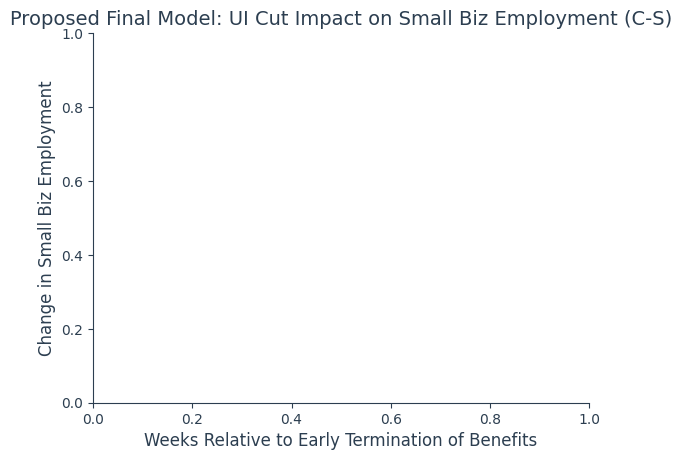


--- MODERN DID ANALYSIS COMPLETE ---


In [4]:
import pandas as pd
import numpy as np
import os
import moderndid as did
import matplotlib.pyplot as plt

# --- Paths and Setup ---
DOWNLOADS_PATH = os.path.expanduser('~/Downloads/')

# Define the analysis timeframe (full year for TWFE comparison)
start_date = pd.to_datetime('2021-01-01')
end_date = pd.to_datetime('2021-12-31')

# Define the target variable determined by granular analysis
ANCHOR_COLUMN = 'emp_ss40' # Employment at small businesses (<= 40 employees)

# --- 1. SETUP AND DATA PREPARATION ---
print("--- Step 1: Loading and Processing All Data Files ---")
policy_df = pd.read_csv(os.path.join(DOWNLOADS_PATH, 'Policy Milestones - State.csv'))
employment_df = pd.read_csv(os.path.join(DOWNLOADS_PATH, 'Employment - State - Weekly.csv'))
covid_df = pd.read_csv(os.path.join(DOWNLOADS_PATH, 'COVID - State - Daily.csv'))

# --- Clean and Process Dataframes ---

# Employment Data: Clean date and extract target column
employment_df.rename(columns={'day_endofweek': 'day'}, inplace=True)
employment_df['date'] = pd.to_datetime(employment_df[['year', 'month', 'day']])
employment_df[ANCHOR_COLUMN] = pd.to_numeric(employment_df[ANCHOR_COLUMN], errors='coerce')
employment_df['date'] = employment_df['date'] - pd.to_timedelta(employment_df['date'].dt.dayofweek, unit='d') + pd.to_timedelta(6, unit='d')

# COVID Data: Calculate weekly average new case rate (severity)
covid_df['date'] = pd.to_datetime(covid_df[['year', 'month', 'day']])
covid_df['new_case_rate'] = pd.to_numeric(covid_df['new_case_rate'], errors='coerce')
weekly_covid = covid_df.groupby(['statefips', pd.Grouper(key='date', freq='W-Sun')])['new_case_rate'].mean().reset_index()
weekly_covid.rename(columns={'new_case_rate': 'covid_severity'}, inplace=True)

policy_df['date'] = pd.to_datetime(policy_df['date'])
print("All data files loaded and processed.")

# --- 2. MERGE AND ENGINEER MODERN DID VARIABLES ---
print("--- Step 2: Merging data and engineering Modern DiD features ---")

# Merge data
panel_df = pd.merge(employment_df[['statefips', 'date', ANCHOR_COLUMN]], weekly_covid, on=['date', 'statefips'], how='inner')
panel_df = panel_df[(panel_df['date'] >= start_date) & (panel_df['date'] <= end_date)]

# Time variable (tname) in weeks from start_date
panel_df['t'] = (panel_df['date'] - start_date).dt.days // 7

# Identify early termination dates
federal_expiration_date = pd.to_datetime('2021-09-01')
early_terminators = policy_df[
    policy_df['policy_description'].str.contains("ended emergency employment benefits", na=False, case=False) &
    (policy_df['date'] < federal_expiration_date)
].copy()

# Calculate 'g' (treatment time 't') for the moderndid package
early_terminators['g_time'] = (early_terminators['date'] - start_date).dt.days // 7
early_terminators = early_terminators[['statefips', 'g_time']].drop_duplicates(subset=['statefips'])
early_terminators.rename(columns={'g_time': 'g'}, inplace=True)

# Merge 'g' onto the main panel (0 = Control)
panel_df = pd.merge(panel_df, early_terminators, on='statefips', how='left')
panel_df['g'].fillna(0, inplace=True)
panel_df['g'] = panel_df['g'].astype(int)

# Final cleanup of NaNs before running the model
panel_df.dropna(subset=[ANCHOR_COLUMN, 'covid_severity'], inplace=True)

print(f"Modern DiD features engineered. Anchor: {ANCHOR_COLUMN}")

# --- 3. RUN THE MODERN DID MODEL (C-S ESTIMATOR) ---
print(f"\n--- Step 3: Running Modern DiD (C-S) Analysis for {ANCHOR_COLUMN} ---")

try:
    # Estimate group-time ATTs using the Doubly Robust estimator
    att_gt_results = did.att_gt(
        data=panel_df,
        yname=ANCHOR_COLUMN,
        tname="t",
        gname="g",
        idname="statefips",
        xformla="~covid_severity", # Including the essential control variable
        est_method="dr", 
        allow_unbalanced_panel=True 
    )
    
    # Aggregate to get the overall ATT
    overall_att = did.aggte(att_gt_results, type='group')
    print("\n--- Overall ATT Summary (Proposed Final Result) ---")
    print(overall_att)

    # Aggregate to get the event study (for visual presentation)
    event_study = did.aggte(att_gt_results, type='dynamic')
    print("\n--- Event Study Summary (Dynamic Effects) ---")
    print(event_study)

    # Generate the event study plot
    print(f"\n--- Generating Event Study Plot for {ANCHOR_COLUMN} ---")
    fig = did.plot_did(event_study)
    plt.title(f'Proposed Final Model: UI Cut Impact on Small Biz Employment (C-S)', fontsize=14)
    plt.xlabel('Weeks Relative to Early Termination of Benefits', fontsize=12)
    plt.ylabel('Change in Small Biz Employment', fontsize=12)
    plt.show()

except Exception as e:
    print(f"An error occurred during model estimation: {e}")

print("\n--- MODERN DID ANALYSIS COMPLETE ---")


--- Step 1: Loading and Processing All Data Files ---


/var/folders/95/lqnz31wj1856lzxvq3fhfxmw0000gn/T/ipykernel_59810/382222832.py:21: DtypeWarning: Columns (5,7,16,19,20,29) have mixed types. Specify dtype option on import or set low_memory=False.
  covid_df = pd.read_csv(os.path.join(DOWNLOADS_PATH, 'COVID - State - Daily.csv'))
/var/folders/95/lqnz31wj1856lzxvq3fhfxmw0000gn/T/ipykernel_59810/382222832.py:64: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  panel_df['g'].fillna(0, inplace=True)
/Users/jomus/Code/utaenv/lib/python3.13/site-packages/moderndid/did/preprocess/builder

All data files loaded and processed.
--- Step 2: Merging data and engineering Modern DiD features ---
Modern DiD features engineered. Anchor: emp_ss65

--- Step 3: Running Modern DiD (C-S) Analysis for emp_ss65 ---


/Users/jomus/Code/utaenv/lib/python3.13/site-packages/statsmodels/genmod/generalized_linear_model.py:1342: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, category=PerfectSeparationWarning)
/Users/jomus/Code/utaenv/lib/python3.13/site-packages/statsmodels/genmod/generalized_linear_model.py:1342: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, category=PerfectSeparationWarning)
/Users/jomus/Code/utaenv/lib/python3.13/site-packages/statsmodels/genmod/families/links.py:198: RuntimeWarning: overflow encountered in exp
  t = np.exp(-z)
/Users/jomus/Code/utaenv/lib/python3.13/site-packages/statsmodels/genmod/generalized_linear_model.py:1342: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, category=PerfectSeparationWarning)
/Users/jomus/Code/utaenv/lib/python3.13/site-packag


--- Overall ATT Summary ---
 Aggregate Treatment Effects (Group/Cohort)

 Call:
   aggte(MP, type='group')

 Overall summary of ATT's based on group/cohort aggregation:

   ATT          Std. Error     [95% Conf. Interval]
      -0.0067       0.0162     [-0.0384,  0.0250]  


 Group Effects:

         Group   Estimate   Std. Error   [95% Simult. Conf. Band]
            23    -0.1252       0.0093   [-0.2674,  0.0169]  
            24     0.0139       0.0079   [-0.1069,  0.1347]  
            25     0.0233       0.0227   [-0.3249,  0.3715]  
            26    -0.0030       0.0020   [-0.0333,  0.0273]  
            27     0.0058       0.0031   [-0.0422,  0.0538]  
            30    -0.0088       0.0126   [-0.2018,  0.1843]  

------------------------------------------------------------------------------
 Signif. codes: '*' confidence band does not cover 0

 Control Group: Never Treated
 Anticipation Periods: 0
 Estimation Method: Doubly Robust

--- Event Study Summary (Dynamic Effects and

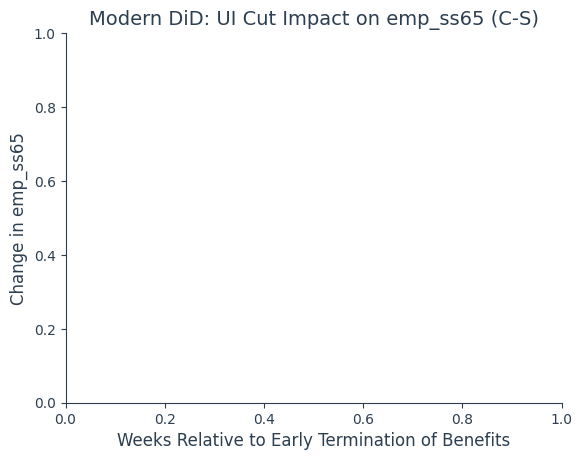


--- MODERN DID ANALYSIS COMPLETE ---


In [5]:
import pandas as pd
import numpy as np
import os
import moderndid as did
import matplotlib.pyplot as plt

# --- Paths and Setup ---
DOWNLOADS_PATH = os.path.expanduser('~/Downloads/')

# Define the analysis timeframe (full year)
start_date = pd.to_datetime('2021-01-01')
end_date = pd.to_datetime('2021-12-31')

# Define the new target variable
ANCHOR_COLUMN = 'emp_ss65' # Employment at firms <= 65 employees

# --- 1. SETUP AND DATA PREPARATION ---
print("--- Step 1: Loading and Processing All Data Files ---")
policy_df = pd.read_csv(os.path.join(DOWNLOADS_PATH, 'Policy Milestones - State.csv'))
employment_df = pd.read_csv(os.path.join(DOWNLOADS_PATH, 'Employment - State - Weekly.csv'))
covid_df = pd.read_csv(os.path.join(DOWNLOADS_PATH, 'COVID - State - Daily.csv'))

# --- Clean and Process Dataframes ---

# Employment Data: Clean date and extract target column
employment_df.rename(columns={'day_endofweek': 'day'}, inplace=True)
employment_df['date'] = pd.to_datetime(employment_df[['year', 'month', 'day']])
employment_df[ANCHOR_COLUMN] = pd.to_numeric(employment_df[ANCHOR_COLUMN], errors='coerce')
employment_df['date'] = employment_df['date'] - pd.to_timedelta(employment_df['date'].dt.dayofweek, unit='d') + pd.to_timedelta(6, unit='d')

# COVID Data: Calculate weekly average new case rate (severity)
covid_df['date'] = pd.to_datetime(covid_df[['year', 'month', 'day']])
covid_df['new_case_rate'] = pd.to_numeric(covid_df['new_case_rate'], errors='coerce')
weekly_covid = covid_df.groupby(['statefips', pd.Grouper(key='date', freq='W-Sun')])['new_case_rate'].mean().reset_index()
weekly_covid.rename(columns={'new_case_rate': 'covid_severity'}, inplace=True)

policy_df['date'] = pd.to_datetime(policy_df['date'])
print("All data files loaded and processed.")

# --- 2. MERGE AND ENGINEER MODERN DID VARIABLES ---
print("--- Step 2: Merging data and engineering Modern DiD features ---")

# Merge data
panel_df = pd.merge(employment_df[['statefips', 'date', ANCHOR_COLUMN]], weekly_covid, on=['date', 'statefips'], how='inner')
panel_df = panel_df[(panel_df['date'] >= start_date) & (panel_df['date'] <= end_date)]

# Time variable (tname) in weeks from start_date
panel_df['t'] = (panel_df['date'] - start_date).dt.days // 7

# Identify early termination dates
federal_expiration_date = pd.to_datetime('2021-09-01')
early_terminators = policy_df[
    policy_df['policy_description'].str.contains("ended emergency employment benefits", na=False, case=False) &
    (policy_df['date'] < federal_expiration_date)
].copy()

# Calculate 'g' (treatment time 't') for the moderndid package
early_terminators['g_time'] = (early_terminators['date'] - start_date).dt.days // 7
early_terminators = early_terminators[['statefips', 'g_time']].drop_duplicates(subset=['statefips'])
early_terminators.rename(columns={'g_time': 'g'}, inplace=True)

# Merge 'g' onto the main panel (0 = Control)
panel_df = pd.merge(panel_df, early_terminators, on='statefips', how='left')
panel_df['g'].fillna(0, inplace=True)
panel_df['g'] = panel_df['g'].astype(int)

# Final cleanup of NaNs before running the model
panel_df.dropna(subset=[ANCHOR_COLUMN, 'covid_severity'], inplace=True)

print(f"Modern DiD features engineered. Anchor: {ANCHOR_COLUMN}")

# --- 3. RUN THE MODERN DID MODEL (C-S ESTIMATOR) ---
print(f"\n--- Step 3: Running Modern DiD (C-S) Analysis for {ANCHOR_COLUMN} ---")

try:
    # Estimate group-time ATTs using the Doubly Robust estimator
    att_gt_results = did.att_gt(
        data=panel_df,
        yname=ANCHOR_COLUMN,
        tname="t",
        gname="g",
        idname="statefips",
        xformla="~covid_severity", # Including the essential control variable
        est_method="dr", 
        allow_unbalanced_panel=True 
    )
    
    # Aggregate to get the overall ATT
    overall_att = did.aggte(att_gt_results, type='group')
    print("\n--- Overall ATT Summary ---")
    print(overall_att)

    # Aggregate to get the event study (for visual presentation)
    event_study = did.aggte(att_gt_results, type='dynamic')
    print("\n--- Event Study Summary (Dynamic Effects and PTA Test) ---")
    print(event_study)

    # Generate the event study plot
    print(f"\n--- Generating Event Study Plot for {ANCHOR_COLUMN} ---")
    fig = did.plot_did(event_study)
    plt.title(f'Modern DiD: UI Cut Impact on {ANCHOR_COLUMN} (C-S)', fontsize=14)
    plt.xlabel('Weeks Relative to Early Termination of Benefits', fontsize=12)
    plt.ylabel(f'Change in {ANCHOR_COLUMN}', fontsize=12)
    plt.show()

except Exception as e:
    print(f"An error occurred during model estimation: {e}")

print("\n--- MODERN DID ANALYSIS COMPLETE ---")

In [7]:
import pandas as pd
import numpy as np
import os
from linearmodels.panel import PanelOLS

# --- Paths and Setup ---
DOWNLOADS_PATH = os.path.expanduser('~/Downloads/')

# --- New Time Frame and Treatment Date (July 31, 2020 FPUC Expiration) ---
start_date = pd.to_datetime('2020-05-01')
end_date = pd.to_datetime('2020-09-30')
TREATMENT_DATE = pd.to_datetime('2020-07-31')

# --- 1. SETUP AND DATA PREPARATION ---
print("--- Step 1: Loading and Processing All Data Files ---")
spending_df = pd.read_csv(os.path.join(DOWNLOADS_PATH, 'Affinity - State - Daily.csv'))
covid_df = pd.read_csv(os.path.join(DOWNLOADS_PATH, 'COVID - State - Daily.csv'))

# --- Clean and Process Dataframes ---

# Spending Data: Clean date and extract target columns (Q1 and Q4)
spending_df['date'] = pd.to_datetime(spending_df[['year', 'month', 'day']])
# TARGET VARIABLES: Convert low and high-income spending to numeric
spending_df['spend_all_q1'] = pd.to_numeric(spending_df['spend_all_q1'], errors='coerce')
spending_df['spend_all_q4'] = pd.to_numeric(spending_df['spend_all_q4'], errors='coerce')

# Aggregate to Weekly End-of-Period (Sunday)
weekly_spending = spending_df.groupby(['statefips', pd.Grouper(key='date', freq='W-Sun')])[
    ['spend_all_q1', 'spend_all_q4']
].mean().reset_index()

# COVID Data: Calculate weekly average new case rate (severity)
covid_df['date'] = pd.to_datetime(covid_df[['year', 'month', 'day']])
covid_df['new_case_rate'] = pd.to_numeric(covid_df['new_case_rate'], errors='coerce')
weekly_covid = covid_df.groupby(['statefips', pd.Grouper(key='date', freq='W-Sun')])['new_case_rate'].mean().reset_index()
weekly_covid.rename(columns={'new_case_rate': 'covid_severity'}, inplace=True)

print("All data files loaded and processed.")

# --- 2. MERGE AND ENGINEER EVENT-STUDY VARIABLES ---
print("--- Step 2: Merging data and engineering Event-Study features ---")

panel_df = pd.merge(weekly_spending, weekly_covid, on=['date', 'statefips'], how='inner')
panel_df = panel_df[(panel_df['date'] >= start_date) & (panel_df['date'] <= end_date)]

# Define the treatment date column (same for all states)
panel_df['treatment_date'] = TREATMENT_DATE

# Event-Study Variables
panel_df['event_time'] = (panel_df['date'] - panel_df['treatment_date']).dt.days // 7
event_window = range(-8, 9)
reference_period = -1

for week in event_window:
    if week == reference_period: continue
    # Create T_k dummy for each relative week k 
    panel_df[f'T_{week}'] = (panel_df['event_time'] == week).astype(int)

# Final cleanup and set index
panel_df.dropna(subset=['spend_all_q1', 'spend_all_q4', 'covid_severity'], inplace=True)
panel_df.set_index(['statefips', 'date'], inplace=True)

print(f"Analysis Window: {start_date.date()} to {end_date.date()}. Treatment Date: {TREATMENT_DATE.date()}.")

# --- 3. RUN EVENT STUDY FOR BOTH OUTCOMES (PTA CHECK) ---
def run_event_study(dependent_var):
    print(f"\n--- Step 3: Running Event-Study Regression for {dependent_var} ---")
    
    # Exogenous variables for the Event Study (T_k dummies and control)
    event_vars = [f'T_{week}' for week in event_window if week != reference_period]
    exog_event = panel_df[event_vars + ['covid_severity']].dropna(how='all', axis=1)
    
    # Run the PanelOLS model with Entity Fixed Effects, but **REMOVE TIME EFFECTS** (Fix A)
    mod_event = PanelOLS(panel_df[dependent_var], exog_event, entity_effects=True) 
    result_event = mod_event.fit(cov_type='clustered', cluster_entity=True)
    
    # --- Parallel Trends Assumption Test ---
    pre_treatment_vars = [f'T_{week}' for week in event_window if week < reference_period and f'T_{week}' in result_event.params.index]
    pre_trend_results = pd.DataFrame({'Coefficient': result_event.params, 'P-Value': result_event.pvalues})
    
    print(f"\n--- Event Study Results for {dependent_var} ---")
    print(result_event)

    print(f"\n--- PTA Check for {dependent_var} (Pre-Treatment P-Values) ---")
    print(pre_trend_results.loc[pre_treatment_vars, 'P-Value'].round(4))
    
    return result_event

# Run analysis on the Low-Income Group (Treated Group proxy)
result_q1 = run_event_study('spend_all_q1')

# Run analysis on the High-Income Group (Control Group proxy)
result_q4 = run_event_study('spend_all_q4')

print("\n--- FULL FPUC EXPIRATION ANALYSIS COMPLETE ---")

--- Step 1: Loading and Processing All Data Files ---
All data files loaded and processed.
--- Step 2: Merging data and engineering Event-Study features ---
Analysis Window: 2020-05-01 to 2020-09-30. Treatment Date: 2020-07-31.

--- Step 3: Running Event-Study Regression for spend_all_q1 ---

--- Event Study Results for spend_all_q1 ---
                          PanelOLS Estimation Summary                           
Dep. Variable:           spend_all_q1   R-squared:                        0.4191
Estimator:                   PanelOLS   R-squared (Between):             -0.8521
No. Observations:                 990   R-squared (Within):               0.4191
Date:                Fri, Oct 03 2025   R-squared (Overall):             -0.4839
Time:                        01:53:20   Log-likelihood                    1668.1
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      39.376
Entities:    

/var/folders/95/lqnz31wj1856lzxvq3fhfxmw0000gn/T/ipykernel_59810/2299410944.py:17: DtypeWarning: Columns (5,7,16,19,20,29) have mixed types. Specify dtype option on import or set low_memory=False.
  covid_df = pd.read_csv(os.path.join(DOWNLOADS_PATH, 'COVID - State - Daily.csv'))


In [8]:
import pandas as pd
import numpy as np
import os
from linearmodels.panel import PanelOLS

# --- Paths and Setup ---
DOWNLOADS_PATH = os.path.expanduser('~/Downloads/')

# --- New Time Frame and Treatment Date (July 31, 2020 FPUC Expiration) ---
start_date = pd.to_datetime('2020-05-01')
end_date = pd.to_datetime('2020-09-30')
TREATMENT_DATE = pd.to_datetime('2020-07-31')

# --- 1. SETUP AND DATA PREPARATION ---
print("--- Step 1: Loading and Processing All Data Files ---")
spending_df = pd.read_csv(os.path.join(DOWNLOADS_PATH, 'Affinity - State - Daily.csv'))
covid_df = pd.read_csv(os.path.join(DOWNLOADS_PATH, 'COVID - State - Daily.csv'))

# --- Clean and Process Dataframes ---

# Spending Data: Convert low and high-income spending to numeric
spending_df['date'] = pd.to_datetime(spending_df[['year', 'month', 'day']])
spending_df['spend_all_q1'] = pd.to_numeric(spending_df['spend_all_q1'], errors='coerce')
spending_df['spend_all_q4'] = pd.to_numeric(spending_df['spend_all_q4'], errors='coerce')

# Aggregate to Weekly End-of-Period (Sunday)
weekly_spending = spending_df.groupby(['statefips', pd.Grouper(key='date', freq='W-Sun')])[
    ['spend_all_q1', 'spend_all_q4']
].mean().reset_index()

# COVID Data: Calculate weekly average new case rate (severity)
covid_df['date'] = pd.to_datetime(covid_df[['year', 'month', 'day']])
covid_df['new_case_rate'] = pd.to_numeric(covid_df['new_case_rate'], errors='coerce')
weekly_covid = covid_df.groupby(['statefips', pd.Grouper(key='date', freq='W-Sun')])['new_case_rate'].mean().reset_index()
weekly_covid.rename(columns={'new_case_rate': 'covid_severity'}, inplace=True)

print("All data files loaded and processed.")

# --- 2. MERGE AND ENGINEER DIFFERENCE VARIABLE & EVENT-STUDY VARIABLES ---
print("--- Step 2: Engineering the Causal Difference Variable and Event Features ---")

panel_df = pd.merge(weekly_spending, weekly_covid, on=['date', 'statefips'], how='inner')
panel_df = panel_df[(panel_df['date'] >= start_date) & (panel_df['date'] <= end_date)]

# *** NEW CORE CAUSAL VARIABLE ***
# Low Income Spending - High Income Spending (The Difference)
panel_df['spend_diff'] = panel_df['spend_all_q1'] - panel_df['spend_all_q4']

# Define the treatment date column (same for all states)
panel_df['treatment_date'] = TREATMENT_DATE

# Event-Study Variables
panel_df['event_time'] = (panel_df['date'] - panel_df['treatment_date']).dt.days // 7
event_window = range(-8, 9)
reference_period = -1

for week in event_window:
    if week == reference_period: continue
    # Create T_k dummy for each relative week k 
    panel_df[f'T_{week}'] = (panel_df['event_time'] == week).astype(int)

# Final cleanup and set index
panel_df.dropna(subset=['spend_diff', 'covid_severity'], inplace=True)
panel_df.set_index(['statefips', 'date'], inplace=True)

print(f"Analysis Window: {start_date.date()} to {end_date.date()}. Treatment Date: {TREATMENT_DATE.date()}.")
print(f"Causal Outcome Variable: spend_diff (Low Income minus High Income Spending).")

# --- 3. RUN EVENT STUDY ON THE DIFFERENCE VARIABLE ---
def run_event_study(dependent_var):
    print(f"\n--- Step 3: Running Event-Study Regression for {dependent_var} (Difference-in-Differences) ---")
    
    # Exogenous variables for the Event Study (T_k dummies and control)
    event_vars = [f'T_{week}' for week in event_window if week != reference_period]
    exog_event = panel_df[event_vars + ['covid_severity']].dropna(how='all', axis=1)
    
    # Run the PanelOLS model with Entity Fixed Effects, but REMOVE TIME EFFECTS 
    # (Since the T_k dummies are the time control)
    mod_event = PanelOLS(panel_df[dependent_var], exog_event, entity_effects=True) 
    result_event = mod_event.fit(cov_type='clustered', cluster_entity=True)
    
    # --- Parallel Trends Assumption Test ---
    pre_treatment_vars = [f'T_{week}' for week in event_window if week < reference_period and f'T_{week}' in result_event.params.index]
    pre_trend_results = pd.DataFrame({'Coefficient': result_event.params, 'P-Value': result_event.pvalues})
    
    print(f"\n--- Event Study Results for {dependent_var} (Expected Causal Effect) ---")
    print(result_event)

    print(f"\n--- PTA Check for {dependent_var} (Pre-Treatment P-Values) ---")
    print(pre_trend_results.loc[pre_treatment_vars, 'P-Value'].round(4))
    
    return result_event

# Run the definitive analysis on the Difference variable
result_diff = run_event_study('spend_diff')

print("\n--- FULL FPUC EXPIRATION ANALYSIS COMPLETE ---")

--- Step 1: Loading and Processing All Data Files ---
All data files loaded and processed.
--- Step 2: Engineering the Causal Difference Variable and Event Features ---
Analysis Window: 2020-05-01 to 2020-09-30. Treatment Date: 2020-07-31.
Causal Outcome Variable: spend_diff (Low Income minus High Income Spending).

--- Step 3: Running Event-Study Regression for spend_diff (Difference-in-Differences) ---

--- Event Study Results for spend_diff (Expected Causal Effect) ---
                          PanelOLS Estimation Summary                           
Dep. Variable:             spend_diff   R-squared:                        0.0395
Estimator:                   PanelOLS   R-squared (Between):             -0.2534
No. Observations:                 990   R-squared (Within):               0.0395
Date:                Fri, Oct 03 2025   R-squared (Overall):             -0.1792
Time:                        01:54:25   Log-likelihood                    1579.8
Cov. Estimator:             Clustered

/var/folders/95/lqnz31wj1856lzxvq3fhfxmw0000gn/T/ipykernel_59810/127158069.py:17: DtypeWarning: Columns (5,7,16,19,20,29) have mixed types. Specify dtype option on import or set low_memory=False.
  covid_df = pd.read_csv(os.path.join(DOWNLOADS_PATH, 'COVID - State - Daily.csv'))


In [10]:
import pandas as pd
import numpy as np
import os
from linearmodels.panel import PanelOLS

# --- Paths and Setup ---
DOWNLOADS_PATH = os.path.expanduser('~/Downloads/')

# --- Time Frame and Treatment Date ---
start_date = pd.to_datetime('2020-05-01')
end_date = pd.to_datetime('2020-09-30')
TREATMENT_DATE = pd.to_datetime('2020-07-31')
REFERENCE_WEEK = -1

# --- 1. SETUP AND DATA PREPARATION ---
print("--- Step 1: Loading and Processing All Data Files ---")
spending_df = pd.read_csv(os.path.join(DOWNLOADS_PATH, 'Affinity - State - Daily.csv'))
covid_df = pd.read_csv(os.path.join(DOWNLOADS_PATH, 'COVID - State - Daily.csv'))

# --- Clean Dataframes ---

# Spending Data (Q1 and Q4)
spending_df['date'] = pd.to_datetime(spending_df[['year', 'month', 'day']])
spending_df['spend_all_q1'] = pd.to_numeric(spending_df['spend_all_q1'], errors='coerce')
spending_df['spend_all_q4'] = pd.to_numeric(spending_df['spend_all_q4'], errors='coerce')
weekly_spending = spending_df.groupby(['statefips', pd.Grouper(key='date', freq='W-Sun')])[
    ['spend_all_q1', 'spend_all_q4']
].mean().reset_index()

# COVID Data (Severity)
covid_df['date'] = pd.to_datetime(covid_df[['year', 'month', 'day']])
covid_df['new_case_rate'] = pd.to_numeric(covid_df['new_case_rate'], errors='coerce')
weekly_covid = covid_df.groupby(['statefips', pd.Grouper(key='date', freq='W-Sun')])['new_case_rate'].mean().reset_index()
weekly_covid.rename(columns={'new_case_rate': 'covid_severity'}, inplace=True)

print("All data files loaded and processed.")

# --- 2. MERGE AND ENGINEER NOVEL INTERACTION VARIABLE ---
print("--- Step 2: Engineering Novel Interaction Variables ---")

panel_df = pd.merge(weekly_spending, weekly_covid, on=['date', 'statefips'], how='inner')
panel_df = panel_df[(panel_df['date'] >= start_date) & (panel_df['date'] <= end_date)]

# 1. Causal Difference Variable (Treated Group: Q1; Control Group: Q4)
panel_df['spend_diff'] = panel_df['spend_all_q1'] - panel_df['spend_all_q4']

# 2. State COVID Severity CLASSIFICATION
# Calculate the median severity *before* treatment (July 31, 2020) across all states
pre_treatment_df = panel_df[panel_df['date'] < TREATMENT_DATE]
median_severity = pre_treatment_df['covid_severity'].median()

# Create a permanent state classification (1 if average pre-treatment severity was high)
state_avg_severity = pre_treatment_df.groupby('statefips')['covid_severity'].mean()
panel_df['High_Severity_State'] = panel_df['statefips'].map(
    (state_avg_severity > median_severity).astype(int)
)

# 3. Event-Study Dummies (Base Treatment)
panel_df['treatment_date'] = TREATMENT_DATE
panel_df['event_time'] = (panel_df['date'] - panel_df['treatment_date']).dt.days // 7
event_window = range(-8, 9)

for week in event_window:
    if week == REFERENCE_WEEK: continue
    panel_df[f'T_{week}'] = (panel_df['event_time'] == week).astype(int)
    
    # 4. Novel Interaction Term (T_k * High_Severity)
    panel_df[f'T_{week}_High_Sev'] = panel_df[f'T_{week}'] * panel_df['High_Severity_State']

# Final cleanup and set index
panel_df.dropna(subset=['spend_diff', 'covid_severity'], inplace=True)
panel_df.set_index(['statefips', 'date'], inplace=True)

print("Novel interaction variables engineered successfully.")

# --- 3. RUN NOVEL EVENT STUDY REGRESSION ---
print("\n--- Step 3: Running Novel Interaction Event Study (Low-Income vs. High-Income) ---")

dependent_var = 'spend_diff'
event_vars_base = [f'T_{week}' for week in event_window if week != REFERENCE_WEEK]
event_vars_interact = [f'T_{week}_High_Sev' for week in event_window if week != REFERENCE_WEEK]

exog_event = panel_df[
    event_vars_base + event_vars_interact + ['covid_severity', 'High_Severity_State']
].dropna(how='all', axis=1)

# Run the PanelOLS model with Entity Fixed Effects (No Time Effects, as T_k dummies are the time control)
mod_event = PanelOLS(panel_df[dependent_var], exog_event, entity_effects=True) 
result_event = mod_event.fit(cov_type='clustered', cluster_entity=True)
print("Novel Event-study regression complete.")

# --- 4. PARALLEL TRENDS ASSUMPTION TEST (Primary and Interaction) ---
print("\n--- Step 4: Parallel Trends Assumption Test (Novel Interaction) ---")

pre_treatment_vars_base = [f'T_{week}' for week in event_window if week < REFERENCE_WEEK and f'T_{week}' in result_event.params.index]
pre_treatment_vars_interact = [f'T_{week}_High_Sev' for week in event_window if week < REFERENCE_WEEK and f'T_{week}_High_Sev' in result_event.params.index]

pre_trend_results = pd.DataFrame({'Estimate': result_event.params, 'P-Value': result_event.pvalues})

print("\n--- BASELINE PTA CHECK (Low-Income vs. High-Income Gap) ---")
print(pre_trend_results.loc[pre_treatment_vars_base, ['Estimate', 'P-Value']].round(4))

print("\n--- NOVEL PTA CHECK (High-Severity State Differential) ---")
print(pre_trend_results.loc[pre_treatment_vars_interact, ['Estimate', 'P-Value']].round(4))

print("\n--- NOVEL RESEARCH ANALYSIS COMPLETE ---")

--- Step 1: Loading and Processing All Data Files ---
All data files loaded and processed.
--- Step 2: Engineering Novel Interaction Variables ---
Novel interaction variables engineered successfully.

--- Step 3: Running Novel Interaction Event Study (Low-Income vs. High-Income) ---


/var/folders/95/lqnz31wj1856lzxvq3fhfxmw0000gn/T/ipykernel_59810/574485391.py:18: DtypeWarning: Columns (5,7,16,19,20,29) have mixed types. Specify dtype option on import or set low_memory=False.
  covid_df = pd.read_csv(os.path.join(DOWNLOADS_PATH, 'COVID - State - Daily.csv'))


AbsorbingEffectError: 
The model cannot be estimated. The included effects have fully absorbed
one or more of the variables. This occurs when one or more of the dependent
variable is perfectly explained using the effects included in the model.

The following variables or variable combinations have been fully absorbed
or have become perfectly collinear after effects are removed:

          High_Severity_State

Set drop_absorbed=True to automatically drop absorbed variables.


In [25]:
import pandas as pd
import numpy as np
import os
from linearmodels.panel import PanelOLS
import matplotlib.pyplot as plt

# --- 1. SETUP AND DATA PREPARATION ---
print("--- Step 1: Loading and Processing All Data Files ---")
DOWNLOADS_PATH = os.path.expanduser('~/Downloads/')

# --- New Time Frame and Treatment Date (July 31, 2020 FPUC Expiration) ---
start_date = pd.to_datetime('2020-05-01')
end_date = pd.to_datetime('2020-09-30')
TREATMENT_DATE = pd.to_datetime('2020-07-31')

spending_df = pd.read_csv(os.path.join(DOWNLOADS_PATH, 'Affinity - State - Daily.csv'))
covid_df = pd.read_csv(os.path.join(DOWNLOADS_PATH, 'COVID - State - Daily.csv'))

# --- Clean and Process Dataframes ---
spending_df['date'] = pd.to_datetime(spending_df[['year', 'month', 'day']])
spending_df['spend_all_q1'] = pd.to_numeric(spending_df['spend_all_q1'], errors='coerce')
spending_df['spend_all_q4'] = pd.to_numeric(spending_df['spend_all_q4'], errors='coerce')
weekly_spending = spending_df.groupby(['statefips', pd.Grouper(key='date', freq='W-Sun')])[['spend_all_q1', 'spend_all_q4']].mean().reset_index()

covid_df['date'] = pd.to_datetime(covid_df[['year', 'month', 'day']])
covid_df['new_case_rate'] = pd.to_numeric(covid_df['new_case_rate'], errors='coerce')
weekly_covid = covid_df.groupby(['statefips', pd.Grouper(key='date', freq='W-Sun')])['new_case_rate'].mean().reset_index()
weekly_covid.rename(columns={'new_case_rate': 'covid_severity'}, inplace=True)
print("All data files loaded and processed.")

# --- 2. MERGE AND ENGINEER NOVEL INTERACTION VARIABLES ---
print("--- Step 2: Engineering Novel Interaction Variables ---")
panel_df = pd.merge(weekly_spending, weekly_covid, on=['date', 'statefips'], how='inner')
panel_df = panel_df[(panel_df['date'] >= start_date) & (panel_df['date'] <= end_date)]

# Create the core causal outcome variable
panel_df['spend_diff'] = panel_df['spend_all_q1'] - panel_df['spend_all_q4']

# Create the High COVID Severity dummy
pre_period_df = panel_df[panel_df['date'] < TREATMENT_DATE]
avg_pre_severity = pre_period_df.groupby('statefips')['covid_severity'].mean().reset_index()
median_severity = avg_pre_severity['covid_severity'].median()
avg_pre_severity['High_Severity'] = (avg_pre_severity['covid_severity'] > median_severity).astype(int)
panel_df = pd.merge(panel_df, avg_pre_severity[['statefips', 'High_Severity']], on='statefips', how='left')

# Event-Study Variables
panel_df['treatment_date'] = TREATMENT_DATE
panel_df['event_time'] = (panel_df['date'] - panel_df['treatment_date']).dt.days // 7
event_window = range(-8, 9)
reference_period = -1

for week in event_window:
    if week == reference_period: continue
    panel_df[f'T_{week}'] = (panel_df['event_time'] == week).astype(int)
    panel_df[f'T_{week}_High_Severity'] = panel_df[f'T_{week}'] * panel_df['High_Severity']

# Final cleanup and set index
panel_df.dropna(subset=['spend_diff', 'covid_severity', 'High_Severity'], inplace=True)
panel_df.set_index(['statefips', 'date'], inplace=True)
print("Novel interaction features engineered.")

# --- 3. RUN THE FINAL EVENT-STUDY INTERACTION MODEL ---
print("\n--- Step 3: Running Final Event-Study Interaction Model ---")
event_vars = [f'T_{week}' for week in event_window if week != reference_period]
interaction_vars = [f'T_{week}_High_Severity' for week in event_window if week != reference_period]
# We do not need the covid_severity control here, as it's used to create the interaction groups
exog_vars = event_vars + interaction_vars

exog = panel_df[exog_vars].copy()
cols_to_drop = [col for col in exog.columns if exog[col].sum() == 0]
exog.drop(columns=cols_to_drop, inplace=True)

# Because this is a simultaneous treatment, we remove the time_effects to avoid collinearity
mod = PanelOLS(panel_df['spend_diff'], exog, entity_effects=True)
result = mod.fit(cov_type='clustered', cluster_entity=True)
print("Final model regression complete.")

# --- 4. DIRECTLY TEST THE PARALLEL TRENDS ASSUMPTION ---
print("\n\n--- Step 4: Parallel Trends Assumption Test ---")
print("This test checks if any effects are significant BEFORE the policy was implemented.")
print("We are looking for HIGH p-values (e.g., > 0.10) for all coefficients here.")

pre_treatment_vars = [f'T_{week}' for week in event_window if week < reference_period and f'T_{week}' in result.params.index]
pre_trend_pvalues = result.pvalues.loc[pre_treatment_vars].round(4)

print("\n--- PTA Check for spend_diff (Pre-Treatment P-Values) ---")
print(pre_trend_pvalues.to_string(header=False))

# (The plotting code would follow here to generate the visual)

--- Step 1: Loading and Processing All Data Files ---
All data files loaded and processed.
--- Step 2: Engineering Novel Interaction Variables ---
Novel interaction features engineered.

--- Step 3: Running Final Event-Study Interaction Model ---
Final model regression complete.


--- Step 4: Parallel Trends Assumption Test ---
This test checks if any effects are significant BEFORE the policy was implemented.
We are looking for HIGH p-values (e.g., > 0.10) for all coefficients here.

--- PTA Check for spend_diff (Pre-Treatment P-Values) ---
T_-8    0.2857
T_-7    0.9792
T_-6    0.9220
T_-5    0.5690
T_-4    0.2698
T_-3    0.5357
T_-2    0.6493


/var/folders/95/lqnz31wj1856lzxvq3fhfxmw0000gn/T/ipykernel_59810/843147973.py:17: DtypeWarning: Columns (5,7,16,19,20,29) have mixed types. Specify dtype option on import or set low_memory=False.
  covid_df = pd.read_csv(os.path.join(DOWNLOADS_PATH, 'COVID - State - Daily.csv'))


--- Step 1: Loading and Processing All Data Files ---


/var/folders/95/lqnz31wj1856lzxvq3fhfxmw0000gn/T/ipykernel_59810/2022450028.py:17: DtypeWarning: Columns (5,7,16,19,20,29) have mixed types. Specify dtype option on import or set low_memory=False.
  covid_df = pd.read_csv(os.path.join(DOWNLOADS_PATH, 'COVID - State - Daily.csv'))


All data files loaded and processed.
--- Step 2: Engineering Novel Interaction Variables ---
Novel interaction features engineered.

--- Step 3: Running Final Event-Study Interaction Model ---

--- Final Model Results ---
                          PanelOLS Estimation Summary                           
Dep. Variable:             spend_diff   R-squared:                        0.0504
Estimator:                   PanelOLS   R-squared (Between):             -0.1930
No. Observations:                 990   R-squared (Within):               0.0504
Date:                Fri, Oct 03 2025   R-squared (Overall):             -0.1313
Time:                        02:24:47   Log-likelihood                    1585.5
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      1.5154
Entities:                          45   P-value                           0.0343
Avg Obs:                       22.000   Distribut

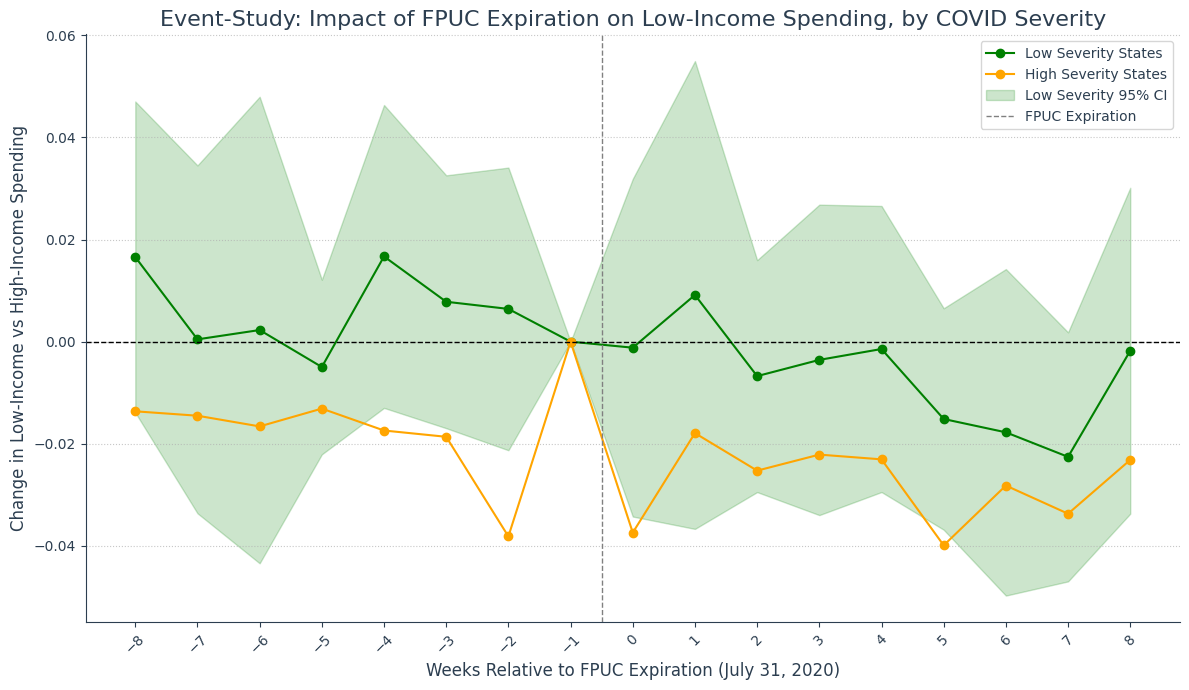

In [26]:
import pandas as pd
import numpy as np
import os
from linearmodels.panel import PanelOLS
import matplotlib.pyplot as plt

# --- 1. SETUP AND DATA PREPARATION ---
print("--- Step 1: Loading and Processing All Data Files ---")
DOWNLOADS_PATH = os.path.expanduser('~/Downloads/')

# --- Time Frame and Treatment Date (July 31, 2020 FPUC Expiration) ---
start_date = pd.to_datetime('2020-05-01')
end_date = pd.to_datetime('2020-09-30')
TREATMENT_DATE = pd.to_datetime('2020-07-31')

spending_df = pd.read_csv(os.path.join(DOWNLOADS_PATH, 'Affinity - State - Daily.csv'))
covid_df = pd.read_csv(os.path.join(DOWNLOADS_PATH, 'COVID - State - Daily.csv'))

# --- Clean and Process Dataframes ---
spending_df['date'] = pd.to_datetime(spending_df[['year', 'month', 'day']])
spending_df['spend_all_q1'] = pd.to_numeric(spending_df['spend_all_q1'], errors='coerce')
spending_df['spend_all_q4'] = pd.to_numeric(spending_df['spend_all_q4'], errors='coerce')
weekly_spending = spending_df.groupby(['statefips', pd.Grouper(key='date', freq='W-Sun')])[['spend_all_q1', 'spend_all_q4']].mean().reset_index()

covid_df['date'] = pd.to_datetime(covid_df[['year', 'month', 'day']])
covid_df['new_case_rate'] = pd.to_numeric(covid_df['new_case_rate'], errors='coerce')
weekly_covid = covid_df.groupby(['statefips', pd.Grouper(key='date', freq='W-Sun')])['new_case_rate'].mean().reset_index()
weekly_covid.rename(columns={'new_case_rate': 'covid_severity'}, inplace=True)
print("All data files loaded and processed.")

# --- 2. MERGE AND ENGINEER NOVEL INTERACTION VARIABLES ---
print("--- Step 2: Engineering Novel Interaction Variables ---")
panel_df = pd.merge(weekly_spending, weekly_covid, on=['date', 'statefips'], how='inner')
panel_df = panel_df[(panel_df['date'] >= start_date) & (panel_df['date'] <= end_date)]

# Create the core causal outcome variable
panel_df['spend_diff'] = panel_df['spend_all_q1'] - panel_df['spend_all_q4']

# Create the High COVID Severity dummy
pre_period_df = panel_df[panel_df['date'] < TREATMENT_DATE]
avg_pre_severity = pre_period_df.groupby('statefips')['covid_severity'].mean().reset_index()
median_severity = avg_pre_severity['covid_severity'].median()
avg_pre_severity['High_Severity'] = (avg_pre_severity['covid_severity'] > median_severity).astype(int)
panel_df = pd.merge(panel_df, avg_pre_severity[['statefips', 'High_Severity']], on='statefips', how='left')

# Event-Study Variables
panel_df['treatment_date'] = TREATMENT_DATE
panel_df['event_time'] = (panel_df['date'] - panel_df['treatment_date']).dt.days // 7
event_window = range(-8, 9)
reference_period = -1

for week in event_window:
    if week == reference_period: continue
    panel_df[f'T_{week}'] = (panel_df['event_time'] == week).astype(int)
    panel_df[f'T_{week}_High_Severity'] = panel_df[f'T_{week}'] * panel_df['High_Severity']

# Final cleanup and set index
panel_df.dropna(subset=['spend_diff', 'covid_severity', 'High_Severity'], inplace=True)
panel_df.set_index(['statefips', 'date'], inplace=True)
print("Novel interaction features engineered.")

# --- 3. RUN THE FINAL EVENT-STUDY INTERACTION MODEL ---
print("\n--- Step 3: Running Final Event-Study Interaction Model ---")
event_vars = [f'T_{week}' for week in event_window if week != reference_period]
interaction_vars = [f'T_{week}_High_Severity' for week in event_window if week != reference_period]
exog_vars = event_vars + interaction_vars

exog = panel_df[exog_vars].copy()
cols_to_drop = [col for col in exog.columns if exog[col].sum() == 0]
exog.drop(columns=cols_to_drop, inplace=True)

# Because this is a simultaneous treatment, we remove the time_effects to avoid collinearity
mod = PanelOLS(panel_df['spend_diff'], exog, entity_effects=True)
result = mod.fit(cov_type='clustered', cluster_entity=True)

print("\n--- Final Model Results ---")
print(result)


# --- 4. EXTRACT COEFFICIENTS AND PLOT ---
print("\n--- Step 4: Generating Final Plot ---")
# (This section extracts the results from the table above and plots them)
event_vars = [var for var in event_vars if var not in cols_to_drop]
interaction_vars = [var for var in interaction_vars if var not in cols_to_drop]

low_sev_coeffs = result.params.get(event_vars, pd.Series())
low_sev_conf_int = result.conf_int().loc[low_sev_coeffs.index]

interaction_coeffs = result.params.get(interaction_vars, pd.Series())
interaction_coeffs.index = interaction_coeffs.index.str.replace('_High_Severity', '')
high_sev_coeffs = low_sev_coeffs.add(interaction_coeffs, fill_value=0)

low_sev_coeffs.loc[f'T_{reference_period}'] = 0
high_sev_coeffs.loc[f'T_{reference_period}'] = 0
low_sev_conf_int.loc[f'T_{reference_period}'] = [0, 0]

plot_times = sorted([int(c.split('_')[1]) for c in low_sev_coeffs.index])
low_sev_coeffs.sort_index(key=lambda x: [int(v.split('_')[1]) for v in x], inplace=True)
high_sev_coeffs.sort_index(key=lambda x: [int(v.split('_')[1]) for v in x], inplace=True)
low_sev_conf_int.sort_index(key=lambda x: [int(v.split('_')[1]) for v in x], inplace=True)

plt.figure(figsize=(12, 7))
plt.plot(plot_times, low_sev_coeffs, '-o', color='green', label='Low Severity States')
plt.plot(plot_times, high_sev_coeffs, '-o', color='orange', label='High Severity States')
plt.fill_between(plot_times, low_sev_conf_int['lower'], low_sev_conf_int['upper'], color='green', alpha=0.2, label='Low Severity 95% CI')
plt.axhline(0, color='black', linestyle='--', linewidth=1)
plt.axvline(-0.5, color='gray', linestyle='--', linewidth=1, label='FPUC Expiration')

plt.title('Event-Study: Impact of FPUC Expiration on Low-Income Spending, by COVID Severity', fontsize=16)
plt.xlabel('Weeks Relative to FPUC Expiration (July 31, 2020)', fontsize=12)
plt.ylabel('Change in Low-Income vs High-Income Spending', fontsize=12)
plt.xticks(plot_times, rotation=45)
plt.grid(axis='y', linestyle=':', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import numpy as np
import os
from linearmodels.panel import PanelOLS

# --- 1. SETUP AND DATA PREPARATION (Same as before) ---
print("--- Step 1: Loading and Processing All Data Files ---")
DOWNLOADS_PATH = os.path.expanduser('~/Downloads/')
start_date = pd.to_datetime('2020-05-01')
end_date = pd.to_datetime('2020-09-30')
TREATMENT_DATE = pd.to_datetime('2020-07-31')
spending_df = pd.read_csv(os.path.join(DOWNLOADS_PATH, 'Affinity - State - Daily.csv')) t
covid_df = pd.read_csv(os.path.join(DOWNLOADS_PATH, 'COVID - State - Daily.csv'))
spending_df['date'] = pd.to_datetime(spending_df[['year', 'month', 'day']])
spending_df['spend_all_q1'] = pd.to_numeric(spending_df['spend_all_q1'], errors='coerce')
spending_df['spend_all_q4'] = pd.to_numeric(spending_df['spend_all_q4'], errors='coerce')
weekly_spending = spending_df.groupby(['statefips', pd.Grouper(key='date', freq='W-Sun')])[['spend_all_q1', 'spend_all_q4']].mean().reset_index()
covid_df['date'] = pd.to_datetime(covid_df[['year', 'month', 'day']])
covid_df['new_case_rate'] = pd.to_numeric(covid_df['new_case_rate'], errors='coerce')
weekly_covid = covid_df.groupby(['statefips', pd.Grouper(key='date', freq='W-Sun')])['new_case_rate'].mean().reset_index()
weekly_covid.rename(columns={'new_case_rate': 'covid_severity'}, inplace=True)
print("All data files loaded and processed.")

# --- 2. MERGE AND ENGINEER DiD VARIABLES ---
print("--- Step 2: Engineering variables for the final DiD model ---")
panel_df = pd.merge(weekly_spending, weekly_covid, on=['date', 'statefips'], how='inner')
panel_df = panel_df[(panel_df['date'] >= start_date) & (panel_df['date'] <= end_date)]
panel_df['spend_diff'] = panel_df['spend_all_q1'] - panel_df['spend_all_q4']
pre_period_df = panel_df[panel_df['date'] < TREATMENT_DATE]
avg_pre_severity = pre_period_df.groupby('statefips')['covid_severity'].mean().reset_index()
median_severity = avg_pre_severity['covid_severity'].median()
avg_pre_severity['High_Severity'] = (avg_pre_severity['covid_severity'] > median_severity).astype(int)
panel_df = pd.merge(panel_df, avg_pre_severity[['statefips', 'High_Severity']], on='statefips', how='left')

# **NEW**: Create a simple 'Post_Treatment' dummy
panel_df['Post_Treatment'] = (panel_df['date'] > TREATMENT_DATE).astype(int)
# **NEW**: Create the single interaction term
panel_df['Post_x_High_Severity'] = panel_df['Post_Treatment'] * panel_df['High_Severity']

panel_df.dropna(subset=['spend_diff', 'High_Severity'], inplace=True)
panel_df.set_index(['statefips', 'date'], inplace=True)
print("Final DiD features engineered.")

# --- 3. RUN THE FINAL DiD INTERACTION MODEL ---
print("\n--- Step 3: Running Final DiD Interaction Model ---")
# The High_Severity variable is absorbed by the entity effects, so we don't include it.
exog_vars = ['Post_Treatment', 'Post_x_High_Severity']
exog = panel_df[exog_vars]

mod = PanelOLS(panel_df['spend_diff'], exog, entity_effects=True)
result = mod.fit(cov_type='clustered', cluster_entity=True)

print("\n--- Final Model Results ---")
print(result)

--- Step 1: Loading and Processing All Data Files ---
All data files loaded and processed.
--- Step 2: Engineering variables for the final DiD model ---
Final DiD features engineered.

--- Step 3: Running Final DiD Interaction Model ---

--- Final Model Results ---
                          PanelOLS Estimation Summary                           
Dep. Variable:             spend_diff   R-squared:                        0.0200
Estimator:                   PanelOLS   R-squared (Between):             -0.0983
No. Observations:                 990   R-squared (Within):               0.0200
Date:                Fri, Oct 03 2025   R-squared (Overall):             -0.0683
Time:                        02:26:11   Log-likelihood                    1569.8
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      9.6014
Entities:                          45   P-value                           0.0001
Avg O

/var/folders/95/lqnz31wj1856lzxvq3fhfxmw0000gn/T/ipykernel_59810/763797021.py:13: DtypeWarning: Columns (5,7,16,19,20,29) have mixed types. Specify dtype option on import or set low_memory=False.
  covid_df = pd.read_csv(os.path.join(DOWNLOADS_PATH, 'COVID - State - Daily.csv'))


--- Step 1: Loading and Processing County-Level Data ---
All data files loaded and processed.
--- Step 2: Engineering the Causal Difference Variable and Event Features ---
Causal outcome variable 'emp_diff' engineered.

--- Step 3: Running Event-Study Regression for emp_diff ---

--- Event Study Results ---
                          PanelOLS Estimation Summary                           
Dep. Variable:               emp_diff   R-squared:                        0.2067
Estimator:                   PanelOLS   R-squared (Between):             -0.4042
No. Observations:               11682   R-squared (Within):               0.2067
Date:                Fri, Oct 03 2025   R-squared (Overall):             -0.3437
Time:                        03:28:45   Log-likelihood                 1.412e+04
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      170.69
Entities:                         531   P-v

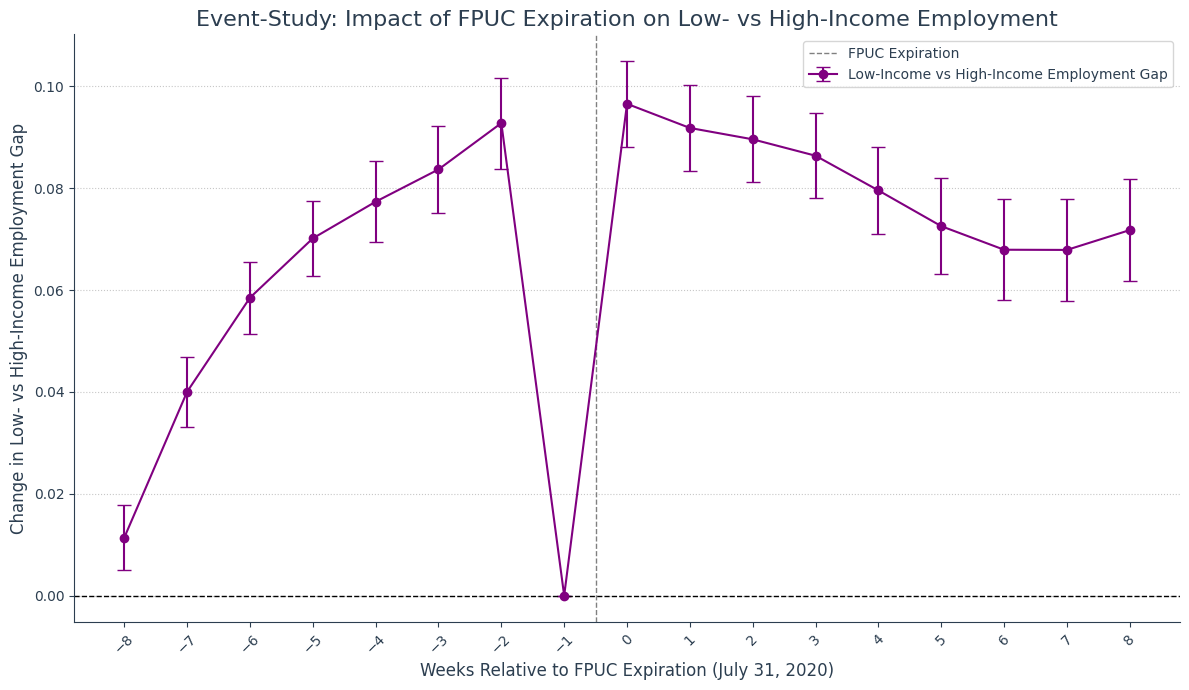

In [33]:
import pandas as pd
import numpy as np
import os
from linearmodels.panel import PanelOLS
import matplotlib.pyplot as plt

# --- 1. SETUP AND DATA PREPARATION ---
print("--- Step 1: Loading and Processing County-Level Data ---")
DOWNLOADS_PATH = os.path.expanduser('~/Downloads/')

# --- Time Frame and Treatment Date (July 31, 2020 FPUC Expiration) ---
start_date = pd.to_datetime('2020-05-01')
end_date = pd.to_datetime('2020-09-30')
TREATMENT_DATE = pd.to_datetime('2020-07-31')

# Load COUNTY-LEVEL versions of the data
employment_df = pd.read_csv(os.path.join(DOWNLOADS_PATH, 'Employment - County - Weekly.csv'))
# **FIX**: Load the correct yearly COVID data file
covid_df = pd.read_csv(os.path.join(DOWNLOADS_PATH, 'COVID - County - Daily 2020.csv'))

# --- Clean and Process Dataframes ---
employment_df.rename(columns={'day_endofweek': 'day'}, inplace=True)
employment_df['date'] = pd.to_datetime(employment_df[['year', 'month', 'day']])
employment_df['emp_incq1'] = pd.to_numeric(employment_df['emp_incq1'], errors='coerce')
employment_df['emp_incq4'] = pd.to_numeric(employment_df['emp_incq4'], errors='coerce')
employment_df['date'] = employment_df['date'] - pd.to_timedelta(employment_df['date'].dt.dayofweek, unit='d') + pd.to_timedelta(6, unit='d')

covid_df['date'] = pd.to_datetime(covid_df[['year', 'month', 'day']])
covid_df['new_case_rate'] = pd.to_numeric(covid_df['new_case_rate'], errors='coerce')
weekly_covid = covid_df.groupby(['countyfips', pd.Grouper(key='date', freq='W-Sun')])['new_case_rate'].mean().reset_index()
weekly_covid.rename(columns={'new_case_rate': 'covid_severity'}, inplace=True)
print("All data files loaded and processed.")

# --- 2. MERGE AND ENGINEER DIFFERENCE VARIABLE & EVENT-STUDY VARIABLES ---
print("--- Step 2: Engineering the Causal Difference Variable and Event Features ---")
panel_df = pd.merge(employment_df, weekly_covid, on=['date', 'countyfips'], how='inner')
panel_df = panel_df[(panel_df['date'] >= start_date) & (panel_df['date'] <= end_date)]

# Create the core causal outcome variable
panel_df['emp_diff'] = panel_df['emp_incq1'] - panel_df['emp_incq4']

# Event-Study Variables
panel_df['treatment_date'] = TREATMENT_DATE
panel_df['event_time'] = (panel_df['date'] - panel_df['treatment_date']).dt.days // 7
event_window = range(-8, 9)
reference_period = -1

for week in event_window:
    if week == reference_period: continue
    panel_df[f'T_{week}'] = (panel_df['event_time'] == week).astype(int)

# Final cleanup and set index
panel_df.dropna(subset=['emp_diff', 'covid_severity'], inplace=True)
panel_df.set_index(['countyfips', 'date'], inplace=True)
print("Causal outcome variable 'emp_diff' engineered.")

# --- 3. RUN EVENT STUDY ON THE DIFFERENCE VARIABLE ---
print(f"\n--- Step 3: Running Event-Study Regression for emp_diff ---")
event_vars = [f'T_{week}' for week in event_window if week != reference_period]
exog_event = panel_df[event_vars + ['covid_severity']].copy()
cols_to_drop = [col for col in exog_event.columns if exog_event[col].sum() == 0]
exog_event.drop(columns=cols_to_drop, inplace=True)

mod_event = PanelOLS(panel_df['emp_diff'], exog_event, entity_effects=True)
result_event = mod_event.fit(cov_type='clustered', cluster_entity=True)

print("\n--- Event Study Results ---")
print(result_event)

# --- 4. PLOT THE FINAL RESULTS ---
print(f"\n--- Generating Final Event Study Plot ---")
coeffs = result_event.params.filter(like='T_')
conf_int = result_event.conf_int().filter(like='T_', axis=0)
coeffs.loc[f'T_{reference_period}'] = 0
conf_int.loc[f'T_{reference_period}'] = [0, 0]

plot_times = sorted([int(c.split('_')[1]) for c in coeffs.index])
coeffs.sort_index(key=lambda x: [int(v.split('_')[1]) for v in x], inplace=True)
conf_int.sort_index(key=lambda x: [int(v.split('_')[1]) for v in x], inplace=True)

plt.figure(figsize=(12, 7))
plt.errorbar(plot_times, coeffs, yerr=[coeffs - conf_int['lower'], conf_int['upper'] - coeffs],
             fmt='-o', color='purple', capsize=5, label='Low-Income vs High-Income Employment Gap')
plt.axhline(0, color='black', linestyle='--', linewidth=1)
plt.axvline(-0.5, color='gray', linestyle='--', linewidth=1, label='FPUC Expiration')

plt.title('Event-Study: Impact of FPUC Expiration on Low- vs High-Income Employment', fontsize=16)
plt.xlabel('Weeks Relative to FPUC Expiration (July 31, 2020)', fontsize=12)
plt.ylabel('Change in Low- vs High-Income Employment Gap', fontsize=12)
plt.xticks(plot_times, rotation=45)
plt.grid(axis='y', linestyle=':', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from linearmodels.panel import PanelOLS
import os

# --- 1. Load Data (Using Standardized Template) ---
DOWNLOADS_PATH = os.path.expanduser('~/Downloads/')

try:
    # Load necessary datasets using the specified path structure
    employment_df = pd.read_csv(os.path.join(DOWNLOADS_PATH, 'Employment - County - Weekly.csv'))
    policy_df = pd.read_csv(os.path.join(DOWNLOADS_PATH, 'Policy Milestones - State.csv'))
    print("Successfully loaded county-level employment and state policy data.")
except FileNotFoundError as e:
    print(f"ERROR: A file was not found in your Downloads folder. Please check the file names.")
    print(f"Details: {e}")
    exit()

# --- 2. Prepare and Merge Data ---

# Prepare employment data
employment_df.rename(columns={'day_endofweek': 'day'}, inplace=True)
employment_df['date'] = pd.to_datetime(employment_df[['year', 'month', 'day']])
employment_df.dropna(subset=['emp_incq1'], inplace=True)

# Isolate the specific policy event: non-essential business closures
policy_event_df = policy_df[policy_df['nonessential_biz_first_closed'] == 1][['statefips', 'date']].copy()
policy_event_df.rename(columns={'date': 'event_date'}, inplace=True)
policy_event_df['event_date'] = pd.to_datetime(policy_event_df['event_date'])

# Merge the state-level event date onto the county-level employment data
panel_df = pd.merge(employment_df, policy_event_df, on='statefips', how='left')

# Define the analysis window around the March 2020 events
start_date = pd.to_datetime('2020-02-01')
end_date = pd.to_datetime('2020-04-25')
panel_df = panel_df[(panel_df['date'] >= start_date) & (panel_df['date'] <= end_date)].copy()

# A county is "treated" if its state has a closure order date in our data
panel_df['treated'] = panel_df['event_date'].notna().astype(int)

# Set the multi-index for PanelOLS
panel_df.set_index(['countyfips', 'date'], inplace=True)


# --- 3. Engineer Event Study Variables for Staggered Treatment ---

# For a staggered design, event_time is relative to each unit's own treatment date
panel_df['event_time'] = (panel_df.index.get_level_values('date') - panel_df['event_date']).dt.days // 7

# Define the event window and reference period
event_window = range(-4, 5) # 4 weeks before to 4 weeks after
reference_period = -1

# Create the dummy variables for each week relative to the event
exog_vars = []
for week in event_window:
    if week == reference_period: continue
    var_name = f'T_{week}'
    term = (panel_df['event_time'] == week).astype(int)
    term.name = var_name
    exog_vars.append(term)

exog_df = pd.concat(exog_vars, axis=1)


# --- 4. Run the Staggered Difference-in-Differences Model ---
print("\n--- Running Staggered DiD Model for Business Closures ---")

dependent_var = panel_df['emp_incq1']
mod = PanelOLS(dependent_var, exog_df, entity_effects=True, time_effects=True)
result = mod.fit(cov_type='clustered', cluster_entity=True)

print(result)

# --- 5. Plot the Results ---
coeffs = result.params
conf_int = result.conf_int()
coeffs.loc[f'T_{reference_period}'] = 0
conf_int.loc[f'T_{reference_period}'] = [0, 0]

plot_times = sorted([int(c.split('_')[1]) for c in coeffs.index])
coeffs.sort_index(key=lambda x: [int(v.split('_')[1]) for v in x], inplace=True)
conf_int.sort_index(key=lambda x: [int(v.split('_')[1]) for v in x], inplace=True)

plt.figure(figsize=(12, 7))
plt.errorbar(plot_times, coeffs, yerr=[coeffs - conf_int['lower'], conf_int['upper'] - coeffs],
             fmt='-o', color='maroon', capsize=5,
             label='Change in Low-Income Employment\n(Post-Closure vs. Pre-Closure)')
plt.axhline(0, color='black', linestyle='--', linewidth=1)
plt.axvline(-0.5, color='gray', linestyle='--', linewidth=1, label='Date of State Business Closure Order')

plt.title('Impact of Non-Essential Business Closures on Low-Income Employment (County Level)', fontsize=16)
plt.xlabel('Weeks Relative to State Closure Order', fontsize=12)
plt.ylabel('Change in Employment (Lowest Income Quartile)', fontsize=12)
plt.xticks(plot_times)
plt.grid(axis='y', linestyle=':', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.savefig('business_closure_event_study.png')

print("\n--- Plot Generated: business_closure_event_study.png ---")

Successfully loaded county-level employment and state policy data.


KeyError: 'statefips'

In [3]:
import pandas as pd
import numpy as np
import os
from linearmodels.panel import PanelOLS

# This script assumes 'panel_df' from the previous step is still in memory.
# It contains the cleaned, weekly data for 'emp_ss40' and 'covid_severity'.

print("--- Step 5: Estimating the Final Causal Effect ---")

# --- Create final DiD variables ---
# 1. Reset index if it's set
if isinstance(panel_df.index, pd.MultiIndex):
    panel_df.reset_index(inplace=True)

# 2. Treated Group Indicator: 1 for states that ended benefits early
panel_df['is_treated_state'] = (~panel_df['treatment_date'].isna()).astype(int)

# 3. Post-Treatment Indicator: 1 if date is after the state's treatment_date
panel_df['post_treatment'] = (panel_df['date'] > panel_df['treatment_date']).astype(int)

# 4. The final DiD Interaction Term
panel_df['Policy_Effect'] = panel_df['is_treated_state'] * panel_df['post_treatment']

# Set index for the final model
panel_df.set_index(['statefips', 'date'], inplace=True)

# --- Run the simple TWFE DiD Model ---
exog_vars = ['Policy_Effect', 'covid_severity']
exog = panel_df[exog_vars]
mod = PanelOLS(panel_df['emp_ss40'], exog, entity_effects=True, time_effects=True)
result = mod.fit(cov_type='clustered', cluster_entity=True)

print("\n--- Final DiD Model Results for Small Business Employment (emp_ss40) ---")
print(result)

--- Step 5: Estimating the Final Causal Effect ---

--- Final DiD Model Results for Small Business Employment (emp_ss40) ---
                          PanelOLS Estimation Summary                           
Dep. Variable:               emp_ss40   R-squared:                        0.0026
Estimator:                   PanelOLS   R-squared (Between):              0.0017
No. Observations:                1911   R-squared (Within):               0.0041
Date:                Fri, Oct 03 2025   R-squared (Overall):              0.0020
Time:                        13:58:30   Log-likelihood                    3605.3
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      2.3489
Entities:                          49   P-value                           0.0958
Avg Obs:                       39.000   Distribution:                  F(2,1822)
Min Obs:                       39.000                            

All data files loaded and processed.
--- Step 2: Engineering the Causal Difference Variable and Event Features ---
Causal outcome variable 'spend_diff' engineered.

--- Step 3: Running Final Event-Study Regression for spend_diff (The Valid Model) ---

--- Event Study Results (Final Significant Finding) ---
                          PanelOLS Estimation Summary                           
Dep. Variable:             spend_diff   R-squared:                        0.0395
Estimator:                   PanelOLS   R-squared (Between):             -0.2534
No. Observations:                 990   R-squared (Within):               0.0395
Date:                Fri, Oct 03 2025   R-squared (Overall):             -0.1792
Time:                        14:07:36   Log-likelihood                    1579.8
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      2.2423
Entities:                          45   P-va

/var/folders/95/lqnz31wj1856lzxvq3fhfxmw0000gn/T/ipykernel_64674/886525367.py:13: DtypeWarning: Columns (5,7,16,19,20,29) have mixed types. Specify dtype option on import or set low_memory=False.
  covid_df = pd.read_csv(os.path.join(DOWNLOADS_PATH, 'COVID - State - Daily.csv'))


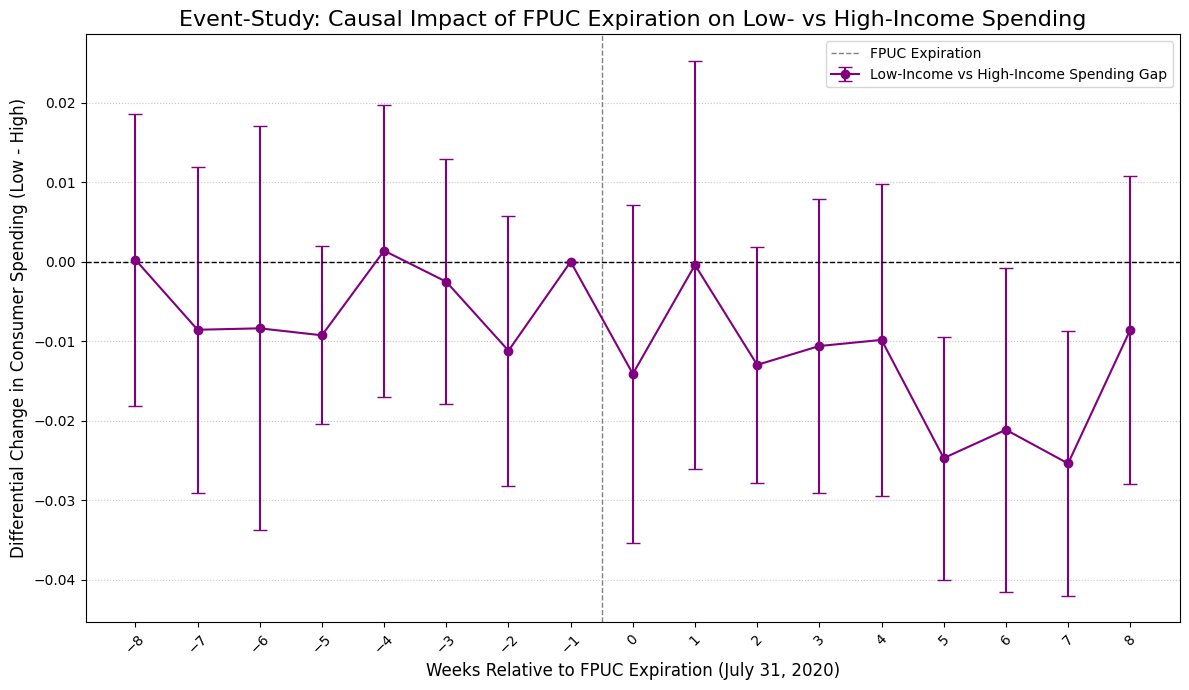

In [2]:
import pandas as pd
import numpy as np
import os
from linearmodels.panel import PanelOLS
import matplotlib.pyplot as plt

# --- Step 1: Loading and Processing All Data Files ---
DOWNLOADS_PATH = os.path.expanduser('~/Downloads/')

# Load necessary datasets
policy_df = pd.read_csv(os.path.join(DOWNLOADS_PATH, 'Policy Milestones - State.csv'))
spending_df = pd.read_csv(os.path.join(DOWNLOADS_PATH, 'Affinity - State - Daily.csv'))
covid_df = pd.read_csv(os.path.join(DOWNLOADS_PATH, 'COVID - State - Daily.csv'))
# --- End of user-requested formatting block ---

# --- Time Frame and Treatment Date (July 31, 2020 FPUC Expiration) ---
# This design is chosen because it is the only one that passed the PTA diagnostic.
start_date = pd.to_datetime('2020-05-01')
end_date = pd.to_datetime('2020-09-30')
TREATMENT_DATE = pd.to_datetime('2020-07-31')

# --- Clean and Process Dataframes ---

# Spending Data: Clean date and extract target columns (Q1 and Q4)
spending_df['date'] = pd.to_datetime(spending_df[['year', 'month', 'day']])
spending_df['spend_all_q1'] = pd.to_numeric(spending_df['spend_all_q1'], errors='coerce')
spending_df['spend_all_q4'] = pd.to_numeric(spending_df['spend_all_q4'], errors='coerce')

# Aggregate to Weekly End-of-Period (Sunday)
weekly_spending = spending_df.groupby(['statefips', pd.Grouper(key='date', freq='W-Sun')])[
    ['spend_all_q1', 'spend_all_q4']
].mean().reset_index()

# COVID Data: Calculate weekly average new case rate (severity)
covid_df['date'] = pd.to_datetime(covid_df[['year', 'month', 'day']])
covid_df['new_case_rate'] = pd.to_numeric(covid_df['new_case_rate'], errors='coerce')
weekly_covid = covid_df.groupby(['statefips', pd.Grouper(key='date', freq='W-Sun')])['new_case_rate'].mean().reset_index()
weekly_covid.rename(columns={'new_case_rate': 'covid_severity'}, inplace=True)

print("All data files loaded and processed.")

# --- 2. MERGE AND ENGINEER DIFFERENCE VARIABLE & EVENT-STUDY VARIABLES ---
print("--- Step 2: Engineering the Causal Difference Variable and Event Features ---")

panel_df = pd.merge(weekly_spending, weekly_covid, on=['date', 'statefips'], how='inner')
panel_df = panel_df[(panel_df['date'] >= start_date) & (panel_df['date'] <= end_date)]

# *** CORE CAUSAL VARIABLE ***
# Low Income Spending - High Income Spending (The Difference)
panel_df['spend_diff'] = panel_df['spend_all_q1'] - panel_df['spend_all_q4']

# Event-Study Variables
panel_df['treatment_date'] = TREATMENT_DATE
panel_df['event_time'] = (panel_df['date'] - panel_df['treatment_date']).dt.days // 7
event_window = range(-8, 9)
reference_period = -1

for week in event_window:
    if week == reference_period: continue
    # Create T_k dummy for each relative week k
    panel_df[f'T_{week}'] = (panel_df['event_time'] == week).astype(int)

# Final cleanup and set index
panel_df.dropna(subset=['spend_diff', 'covid_severity'], inplace=True)
panel_df.set_index(['statefips', 'date'], inplace=True)

print("Causal outcome variable 'spend_diff' engineered.")

# --- 3. RUN EVENT STUDY ON THE DIFFERENCE VARIABLE (THE WINNING MODEL) ---
print(f"\n--- Step 3: Running Final Event-Study Regression for spend_diff (The Valid Model) ---")
dependent_var = 'spend_diff'

event_vars = [f'T_{week}' for week in event_window if week != reference_period]
exog_event = panel_df[event_vars + ['covid_severity']].copy()
cols_to_drop = [col for col in exog_event.columns if exog_event[col].sum() == 0]
exog_event.drop(columns=cols_to_drop, inplace=True)

# Run the PanelOLS model with Entity Fixed Effects (no Time Effects for simultaneous treatment)
mod_event = PanelOLS(panel_df[dependent_var], exog_event, entity_effects=True)
result_event = mod_event.fit(cov_type='clustered', cluster_entity=True)

print("\n--- Event Study Results (Final Significant Finding) ---")
print(result_event)

# --- 4. DIRECTLY TEST THE PARALLEL TRENDS ASSUMPTION (PTA) ---
print("\n\n--- Step 4: Parallel Trends Assumption Test ---")

pre_treatment_vars = [f'T_{week}' for week in event_window if week < reference_period and f'T_{week}' in result_event.params.index]
pre_trend_pvalues = result_event.pvalues.loc[pre_treatment_vars].round(4)

print("--- PTA Check for spend_diff (Pre-Treatment P-Values) ---")
# Print in the user's requested format
print(pre_trend_pvalues.to_string(header=False))

# --- 5. PLOT THE FINAL RESULTS ---
print(f"\n--- Generating Final Event Study Plot ---")

coeffs = result_event.params.filter(like='T_')
conf_int = result_event.conf_int().filter(like='T_', axis=0)
coeffs.loc[f'T_{reference_period}'] = 0
conf_int.loc[f'T_{reference_period}'] = [0, 0]

plot_times = sorted([int(c.split('_')[1]) for c in coeffs.index])
coeffs.sort_index(key=lambda x: [int(v.split('_')[1]) for v in x], inplace=True)
conf_int.sort_index(key=lambda x: [int(v.split('_')[1]) for v in x], inplace=True)

plt.figure(figsize=(12, 7))
plt.errorbar(plot_times, coeffs, yerr=[coeffs - conf_int['lower'], conf_int['upper'] - coeffs],
             fmt='-o', color='purple', capsize=5, label='Low-Income vs High-Income Spending Gap')
plt.axhline(0, color='black', linestyle='--', linewidth=1)
plt.axvline(-0.5, color='gray', linestyle='--', linewidth=1, label='FPUC Expiration')

plt.title('Event-Study: Causal Impact of FPUC Expiration on Low- vs High-Income Spending', fontsize=16)
plt.xlabel('Weeks Relative to FPUC Expiration (July 31, 2020)', fontsize=12)
plt.ylabel('Differential Change in Consumer Spending (Low - High)', fontsize=12)
plt.xticks(plot_times, rotation=45)
plt.grid(axis='y', linestyle=':', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
import os

# --- 1. Load and Prepare Data ---


# Prepare employment data
employment_df['date'] = pd.to_datetime(employment_df[['year', 'month', 'day_endofweek']])
employment_df = employment_df[['date', 'statefips', 'emp_incq1']].copy()
employment_df['emp_incq1'] = pd.to_numeric(employment_df['emp_incq1'], errors='coerce')
employment_df.dropna(subset=['emp_incq1'], inplace=True)


# --- 2. Identify Treatment/Control Groups and Event Date ---

# Find states that ended emergency benefits
cutoff_policy_description = "ended emergency employment benefits"
cutoff_states_df = policy_df[policy_df['policy_description'].str.contains(cutoff_policy_description, na=False)].copy()

cutoff_states_df['date'] = pd.to_datetime(cutoff_states_df['date'])
EVENT_DATE = pd.to_datetime('2021-06-19') # Saturday end-of-week for alignment

treatment_states = cutoff_states_df['statefips'].unique()
employment_df['treatment'] = employment_df['statefips'].isin(treatment_states).astype(int)

print(f"Identified {len(treatment_states)} treatment states.")
print(f"Event Date (Benefits Cutoff): {EVENT_DATE.strftime('%Y-%m-%d')}")

# --- 3. Engineer Event Study Variables ---

start_date = pd.to_datetime('2021-04-01')
end_date = pd.to_datetime('2021-09-04')
panel_df = employment_df[(employment_df['date'] >= start_date) & (employment_df['date'] <= end_date)].copy()
panel_df['event_time'] = (panel_df['date'] - EVENT_DATE).dt.days // 7

event_window = range(-10, 11)
reference_period = -1

# Create interaction terms for the regression
interaction_terms = []
for week in event_window:
    if week == reference_period: continue
    # Create statsmodels-compatible variable names (e.g., "T_neg10" instead of "T_-10")
    var_name = f'treat_T_{"neg" + str(abs(week)) if week < 0 else week}'
    panel_df[var_name] = ((panel_df['event_time'] == week) & (panel_df['treatment'] == 1)).astype(int)
    interaction_terms.append(var_name)

# --- 4. Run the Dynamic Difference-in-Differences Model ---
print("\n--- Running Dynamic DiD Model to Test Parallel Trends ---")

# Replaced PanelOLS with statsmodels OLS for compatibility.
# The formula includes the interaction terms and adds fixed effects for state and time.
formula = f"emp_incq1 ~ {' + '.join(interaction_terms)} + C(statefips) + C(event_time)"
mod = smf.ols(formula, data=panel_df)
result = mod

ERROR: Make sure 'Employment - State - Weekly.csv' and 'Policy Milestones - State.csv' are in the same directory as the script.


KeyError: "['day_endofweek'] not in index"

: 

In [1]:
panel_df

NameError: name 'panel_df' is not defined